In [1]:
import os

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import re

from sklearn.cluster import MiniBatchKMeans
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, ExtraTreesClassifier, RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold, f_regression, SelectKBest, f_classif, SelectFromModel, RFECV
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import warnings
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, MinMaxScaler, StandardScaler, PolynomialFeatures
from sklearn.tree import ExtraTreeRegressor, ExtraTreeClassifier

In [2]:
df = pd.read_csv('../data/used_cars.csv')
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [3]:
def basic_info(df: pd.DataFrame):
    number_of_row = df.shape[0]
    number_of_column = df.shape[1]
    duplicates = df.duplicated().sum()
    mem_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
    print(f'Number of rows: {number_of_row}')
    print(f'Number of columns: {number_of_column}')
    print(f'Duplicates: {duplicates}')
    print(f'Memory usage: {mem_mb:.2f} MB')
basic_info(df)

Number of rows: 4009
Number of columns: 12
Duplicates: 0
Memory usage: 2.58 MB


In [4]:
_BOOL_MAP = {
    "yes": 1, "no": 0, "true": 1, "false": 0,
    "y": 1, "n": 0, "1": 1, "0": 0,
}
_SYMBOL_PATTERN = re.compile(
    r"""
    ^\s*                    # leading whitespace
    [₹$€£¥₩%+\-]?          # optional currency or sign prefix
    [\s]?                   # optional space after symbol
    |                       # OR
    \s*                     # trailing whitespace
    (mi\.?|km\.?|kg\.?|lbs?\.?|mph|kph|hp|cc|°[cf]?|%|[₹$€£¥₩])
    \s*$                    # end
    """,
    re.IGNORECASE | re.VERBOSE,
)
_DATE_CHAR_PATTERN = re.compile(r"[/\-:]|jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec", re.IGNORECASE)

In [5]:
def _strip_to_numeric(value: str) -> str:
    """Remove currency symbols, units, commas from a string value."""
    v = _SYMBOL_PATTERN.sub("", str(value))         # strip prefix/suffix symbols
    v = v.replace(",", "")                          # remove thousand separators
    return v.strip()

In [6]:
def _is_dirty_numeric(series: pd.Series, sample_size: int = 50) -> bool:
    """
    Returns True if the column looks like a number wearing a costume.
    Tests on a sample: strip symbols → try float cast → check success rate.
    """
    sample = series.dropna().head(sample_size)
    if len(sample) == 0:
        return False
    success = 0
    for val in sample:
        try:
            float(_strip_to_numeric(str(val)))
            success += 1
        except ValueError:
            pass
    return (success / len(sample)) >= 0.90   # 90% must parse cleanly

In [7]:
def _is_dirty_boolean(series: pd.Series) -> bool:
    """
    Returns True if all unique non-null values map to yes/no/true/false etc.
    """
    unique_vals = set(series.dropna().astype(str).str.lower().unique())
    return unique_vals.issubset(_BOOL_MAP.keys())

In [8]:
def _is_mostly_numeric(series: pd.Series, threshold: float = 0.85) -> bool:
    """
    Returns True if pd.to_numeric coerces successfully on >threshold fraction.
    Catches columns like ["35", "40", "N/A", "55"] — mostly numeric, few bad rows.
    """
    coerced = pd.to_numeric(series, errors="coerce")
    non_null_original = series.notna().sum()
    if non_null_original == 0:
        return False
    success_rate = coerced.notna().sum() / non_null_original
    return success_rate >= threshold

In [9]:
def _clean_numeric_column(series: pd.Series) -> pd.Series:
    """Strip symbols and cast to float. Unparseable → NaN."""
    def _convert(val):
        try:
            return float(_strip_to_numeric(str(val)))
        except ValueError:
            return np.nan

    return series.apply(_convert)

In [10]:
def _clean_boolean_column(series: pd.Series) -> pd.Series:
    """Map yes/no/true/false → 1/0. Unknowns → NaN."""
    return series.astype(str).str.lower().map(_BOOL_MAP)

In [11]:
def _is_datetime_like(series: pd.Series, sample_size: int = 50, threshold: float = 0.85) -> bool:
    """
    Returns True if the column looks like dates.
    Guards against pure numeric columns (e.g. "2021") being misread as dates
    by requiring date-separator characters or month names in the raw text.
    """
    sample = series.dropna().astype(str).head(sample_size)
    if sample.empty:
        return False

    # require at least one value to contain a date-like character/word
    has_date_chars = sample.str.contains(_DATE_CHAR_PATTERN, regex=True).mean()
    if has_date_chars < 0.5:
        return False

    parsed = pd.to_datetime(sample, errors="coerce", format="mixed")
    success_rate = parsed.notna().mean()
    return success_rate >= threshold


def _clean_datetime_column(series: pd.Series) -> pd.Series:
    """Parse to datetime. Unparseable → NaT."""
    return pd.to_datetime(series, errors="coerce", format="mixed")

In [12]:
def run_basic_cleaning(df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    """
    Detects and fixes dirty columns automatically.

    Pass in the raw loaded DataFrame. Returns:
        - cleaned_df  : DataFrame with corrected dtypes
        - cleaning_report : dict logging what was changed and why
    """
    df = df.copy()
    report = {
        "converted_to_numeric": [],
        "converted_to_boolean": [],
        "coerced_mostly_numeric": [],
        "converted_to_datetime": [],
        "unchanged": [],
    }

    object_cols = df.select_dtypes(include=["object", "string", "category"]).columns

    for col in object_cols:
        series = df[col]

        # ── Priority 0: Datetime check (must run before boolean/numeric) ──────────
        if _is_datetime_like(series):
            df[col] = _clean_datetime_column(series)
            report["converted_to_datetime"].append(col)

        # ── Priority 1: Boolean check first (yes/no cols are also "numeric-ish") ──
        elif _is_dirty_boolean(series):
            df[col] = _clean_boolean_column(series)
            report["converted_to_boolean"].append(col)

        # ── Priority 2: Dirty numeric (currency, units, commas) ───────────────────
        elif _is_dirty_numeric(series):
            df[col] = _clean_numeric_column(series)
            report["converted_to_numeric"].append(col)

        # ── Priority 3: Mostly numeric with a few bad rows ────────────────────────
        elif _is_mostly_numeric(series):
            df[col] = pd.to_numeric(series, errors="coerce")
            report["coerced_mostly_numeric"].append(col)

        # ── No pattern matched: leave as-is for EDA to handle ────────────────────
        else:
            report["unchanged"].append(col)

    return df, report

In [13]:
cleaned_df, report = run_basic_cleaning(df)
cleaned_df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,1.0,10300.0
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,1.0,38005.0
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,54598.0
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,1.0,15500.0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,34999.0


In [14]:
print(report)

{'converted_to_numeric': ['milage', 'price'], 'converted_to_boolean': ['clean_title'], 'coerced_mostly_numeric': [], 'converted_to_datetime': [], 'unchanged': ['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident']}


In [15]:
# test_df = pd.DataFrame({
#     "price": ["$10,300", "$38,005", "$54,598", "$15,500"],
#     "milage": ["51,000 mi.", "34,742 mi.", "22,372 mi.", "88,900 mi."],
#     "clean_title": ["Yes", "Yes", "No", "Yes"],
#     "sale_date": ["2024-01-15", "15/02/2024", "Jan 20, 2024", "2024-03-10"],
#     "model_year": [2013, 2021, 2022, 2015],   # already int — should stay unchanged
# })
# cleaned_df, report = run_basic_cleaning(test_df)
# print(cleaned_df.dtypes)
# print(report)

In [16]:
cleaned_df.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [17]:
## Missing Value report
def missing_value(df: pd.DataFrame):
    column = []
    for col in df:
        if df[col].isnull().any():
            print(col)
            print(df[col].isnull().sum())
            print(f"Missing Using Mean {df[col].isnull().mean() * 100:.2f}%")
            print(f"Missing Value {(df[col].isnull().sum() / len(df))*100:.2f}%")
    return column
print(missing_value(cleaned_df))

fuel_type
170
Missing Using Mean 4.24%
Missing Value 4.24%
accident
113
Missing Using Mean 2.82%
Missing Value 2.82%
clean_title
596
Missing Using Mean 14.87%
Missing Value 14.87%
[]


In [18]:
def missing_value(df: pd.DataFrame) -> pd.DataFrame:
    report = []
    for col in df.columns:
        missing_val = df[col].isnull().sum()
        if missing_val > 0:
            missing_pct = (missing_val / len(df)) * 100
            report.append({
                "Column": col,
                "Missing Count": missing_val,
                "Missing Percentage": missing_pct
            })
    report_df = pd.DataFrame(report)
    if not report_df.empty:
        report_df = report_df.sort_values(by="Missing Percentage", ascending=False).reset_index(drop=True)
    return report_df
report = missing_value(cleaned_df)
print(report)

        Column  Missing Count  Missing Percentage
0  clean_title            596           14.866550
1    fuel_type            170            4.240459
2     accident            113            2.818658


In [19]:
cleaned_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         4009 non-null   str    
 1   model         4009 non-null   str    
 2   model_year    4009 non-null   int64  
 3   milage        4009 non-null   float64
 4   fuel_type     3839 non-null   str    
 5   engine        4009 non-null   str    
 6   transmission  4009 non-null   str    
 7   ext_col       4009 non-null   str    
 8   int_col       4009 non-null   str    
 9   accident      3896 non-null   str    
 10  clean_title   3413 non-null   float64
 11  price         4009 non-null   float64
dtypes: float64(3), int64(1), str(8)
memory usage: 376.0 KB


In [20]:
cleaned_df['price'].kurt()

np.float64(595.8928539362047)

In [21]:
(cleaned_df['price'][1]).item()

38005.0

In [22]:
def Outlier_detection(df: pd.DataFrame):
    numerical_col = df.select_dtypes(include=["number", "float", "int64"]).columns.tolist()
    outlier_report = {}
    for col in numerical_col:
        q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        iqr = q3-q1
        lower_limit = q1 - 1.5 * iqr
        upper_limit = q3 + 1.5 * iqr
        count = 0
        for i in range(df.shape[0]):
            if (df[col][i]).item() < lower_limit:
                count += 1
            elif (df[col][i]).item() > upper_limit:
                count += 1
        print(f"{col} Outlier: {count}")
        outlier_report[col] = count
    return outlier_report
print(Outlier_detection(cleaned_df))

model_year Outlier: 67
milage Outlier: 69
clean_title Outlier: 0
price Outlier: 244
{'model_year': 67, 'milage': 69, 'clean_title': 0, 'price': 244}


In [23]:
cleaned_df.nunique()

brand             57
model           1898
model_year        34
milage          2818
fuel_type          7
engine          1146
transmission      62
ext_col          319
int_col          156
accident           2
clean_title        1
price           1569
dtype: int64

In [24]:
def descriptive_statics(df: pd.DataFrame):
    numerical_col = df.select_dtypes(include=["number", "float", "int64"]).columns.tolist()
    categorical_col = df.select_dtypes(include=["object", "category"]).columns.tolist()
    stats_report = {"numerical": {}, "categorical": {}}
    highly_skewd = []
    # Statics extraction for the numerical columns
    for col in numerical_col:
        mean = df[col].mean()
        median = df[col].median()
        std = df[col].std()
        min = df[col].mean()
        max = df[col].max()
        skewness = df[col].skew()
        if(abs(skewness) > 1):
            highly_skewd.append(col)
        kurtosis = df[col].kurt()
        print(f"Column: {col}")
        print(f"mean: {mean:.4f}")      # The :.4f rounds the number to 4 decimal places for cleaner output
        print(f"median: {median:.4f}")
        print(f"std: {std:.4f}")
        print(f"min: {min:.4f}")
        print(f"max: {max:.4f}")
        print(f"skewness: {skewness:.4f}")
        print(f"kurtosis: {kurtosis:.4f}")
        print("-" * 20)
        stats_report["numerical"][col] = {
            "mean": mean,
            "median": median,
            "std": std,
            "min": min,
            "max": max,
            "skew": skewness,
            "kurtosis": kurtosis
        }
    # Statics extraction for the Categorial columns
    for col in categorical_col:
        counts = df[col].value_counts()
        top_value = counts.index[0]
        top_frequency = counts.iloc[0]
        print(f"Column: {col}")
        print(f"unique count: {len(counts)}")  # Or df[col].nunique()
        print(f"top value: {top_value}")
        print(f"top value frequency: {top_frequency}")
        print("-" * 20)
        stats_report["categorical"][col] = {
            "counts": counts,
            "top_value": top_value,
            "top_frequency": top_frequency,
        }
    return stats_report, highly_skewd

stats_report, highly_skewd = descriptive_statics(cleaned_df)
print(highly_skewd)

Column: model_year
mean: 2015.5156
median: 2017.0000
std: 6.1048
min: 2015.5156
max: 2024.0000
skewness: -1.0892
kurtosis: 1.1016
--------------------
Column: milage
mean: 64717.5510
median: 52775.0000
std: 52296.5995
min: 64717.5510
max: 405000.0000
skewness: 1.1600
kurtosis: 1.7497
--------------------
Column: clean_title
mean: 1.0000
median: 1.0000
std: 0.0000
min: 1.0000
max: 1.0000
skewness: 0.0000
kurtosis: 0.0000
--------------------
Column: price
mean: 44553.1903
median: 31000.0000
std: 78710.6356
min: 44553.1903
max: 2954083.0000
skewness: 19.5136
kurtosis: 595.8929
--------------------
Column: brand
unique count: 57
top value: Ford
top value frequency: 386
--------------------
Column: model
unique count: 1898
top value: M3 Base
top value frequency: 30
--------------------
Column: fuel_type
unique count: 7
top value: Gasoline
top value frequency: 3309
--------------------
Column: engine
unique count: 1146
top value: 2.0L I4 16V GDI DOHC Turbo
top value frequency: 52
----------

C:\Users\Shyam\AppData\Local\Temp\ipykernel_2244\752537469.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_col = df.select_dtypes(include=["object", "category"]).columns.tolist()


In [25]:
categorical_col = cleaned_df.select_dtypes(include=["object", "category"]).columns.tolist()
categorical_col

C:\Users\Shyam\AppData\Local\Temp\ipykernel_2244\1863873601.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_col = cleaned_df.select_dtypes(include=["object", "category"]).columns.tolist()


['brand',
 'model',
 'fuel_type',
 'engine',
 'transmission',
 'ext_col',
 'int_col',
 'accident']

In [26]:
def check_cardianility(df: pd.DataFrame) -> pd.DataFrame:
    report = {
        "Low Cardinality Prefer One Hot": set(),
        "High Cardinality Prefer Target / Feature Encoding": set(),
        "Flagged as Quasi-Constant! Consider dropping": set()
    }
    categorical_col = df.select_dtypes(include=["object", "category"]).columns.tolist()
    for col in categorical_col:
        # Edge case: If a column is completely empty, skip it to avoid errors
        if df[col].dropna().empty:
            continue
        dominant_value_percentage = df[col].value_counts(normalize=True).iloc[0]
        unique_count = df[col].nunique()
        if dominant_value_percentage > 0.95:
            report["Flagged as Quasi-Constant! Consider dropping"].add(col)
        if unique_count <= 10:
            report["Low Cardinality Prefer One Hot"].add(col)
        else:
            report["High Cardinality Prefer Target / Feature Encoding"].add(col)
    return report
print(check_cardianility(cleaned_df))

{'Low Cardinality Prefer One Hot': {'fuel_type', 'accident'}, 'High Cardinality Prefer Target / Feature Encoding': {'transmission', 'ext_col', 'brand', 'model', 'engine', 'int_col'}, 'Flagged as Quasi-Constant! Consider dropping': set()}


C:\Users\Shyam\AppData\Local\Temp\ipykernel_2244\897416054.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_col = df.select_dtypes(include=["object", "category"]).columns.tolist()


## Target Column Analysis

In [27]:
def load_user_data(file):
    extension = Path(file).suffix.lower()
    try:
        if extension == '.csv':
            df = pd.read_csv(file)
        elif extension in ['.xlsx', '.xls']:
            df = pd.read_excel(file)
        elif extension == '.json':
            df = pd.read_json(file)
        else:
            raise ValueError('File extension not supported')
        return df
    except Exception as e:
        print(f'An error occurred:{e}')
        return None
df = load_user_data("../data/classification_sample.xlsx")

In [28]:
def determine_type_of_PS(df, target_col=None):
    if target_col is None:
        print("It is Clustering")
        return "Clustering", None
    if target_col not in df.columns:
        raise ValueError(f'Column: {target_col} is not in the dataframe')
    y = df[target_col]
    uniques_values = y.nunique()
    total_rows = len(df)
    is_text = pd.api.types.is_object_dtype(y) or pd.api.types.is_string_dtype(y)
    is_category = (y.dtype.name == 'category')
    is_bool = pd.api.types.is_bool_dtype(y)
    if is_text or is_category or is_bool:
        return "Classification", target_col
    elif pd.api.types.is_numeric_dtype(y):
        if uniques_values < 15 and (total_rows > uniques_values*2):
            return "Clustering", target_col
        else:
            return "Regression", target_col
    else:
        return "Unknown", target_col
classification, taget_col = determine_type_of_PS(load_user_data(Path("../data/used_cars.csv")), target_col="price")
print(classification, taget_col)

Classification price


In [29]:
def target_column_analysis(df: pd.DataFrame, task_type: str, target_col: str):
    if task_type == "Clustering":
        return None
    if target_col not in df.columns:
        print("Column is not found in the dataframe")
        return None
    y = df[target_col]
    if task_type == "Classification":
        counts = y.value_counts()
        percentage = y.value_counts(normalize=True) * 100
        print(f"Target column: {target_col}")
        print(f"Number of classes: {y.nunique()}")
        print(counts)
        print(percentage.round(2))
        # Plot
        plt.figure(figsize=(8, 5))
        sns.countplot(x=y)
        plt.title(f"Class Distribution — {target_col}")
        plt.xlabel(target_col)
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        # Imbalance Ratio
        imbalance_ratio = counts.max() / counts.min()
        print(f"Imbalance ratio (majority/minority): {imbalance_ratio:.2f}")
        # ── Flag minority classes < 5% share ────────────────────────────
        minority_classes = percentage[percentage < 5]
        is_imbalanced = not minority_classes.empty
        if is_imbalanced:
            print("⚠️ Class imbalance detected — classes under 5% share:")
            print(minority_classes.round(2))
        else:
            print("Class distribution looks balanced")

        return {
            "class_counts": counts.to_dict(),
            "class_percentages": percentage.to_dict(),
            "imbalance_ratio": imbalance_ratio,
            "is_imbalanced": is_imbalanced,
            "minority_classes": minority_classes.index.tolist()
        }
    elif task_type == "Regression":
        # ── Distribution plot ────────────────────────────────────────────
        plt.figure(figsize=(8, 5))
        sns.histplot(y, kde=True)
        plt.title(f"Target Distribution — {target_col}")
        plt.xlabel(target_col)
        plt.tight_layout()
        plt.show()
        # ── Skewness ─────────────────────────────────────────────────────
        skewness = y.skew()
        is_skewed = abs(skewness) > 1
        print(f"Target column: {target_col}")
        print(f"Skewness: {skewness:.3f}")
        if is_skewed:
            print("⚠️ Target is highly skewed — consider log transform")
        else:
            print("Target distribution looks roughly normal")
        return {
            "skewness": skewness,
            "is_skewed": is_skewed,
            "mean": y.mean(),
            "median": y.median(),
            "std": y.std()
        }
    else:
        print(f"Unknown task_type: {task_type} — skipping target analysis")
        return None

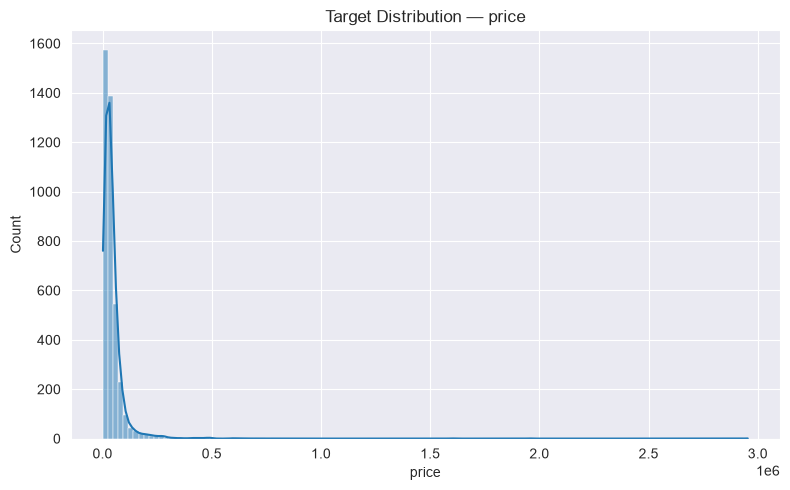

Target column: price
Skewness: 19.514
⚠️ Target is highly skewed — consider log transform
{'skewness': np.float64(19.51355120421606), 'is_skewed': np.True_, 'mean': np.float64(44553.190321776005), 'median': np.float64(31000.0), 'std': np.float64(78710.635554182)}


In [30]:
print(target_column_analysis(cleaned_df, "Regression", "price"))

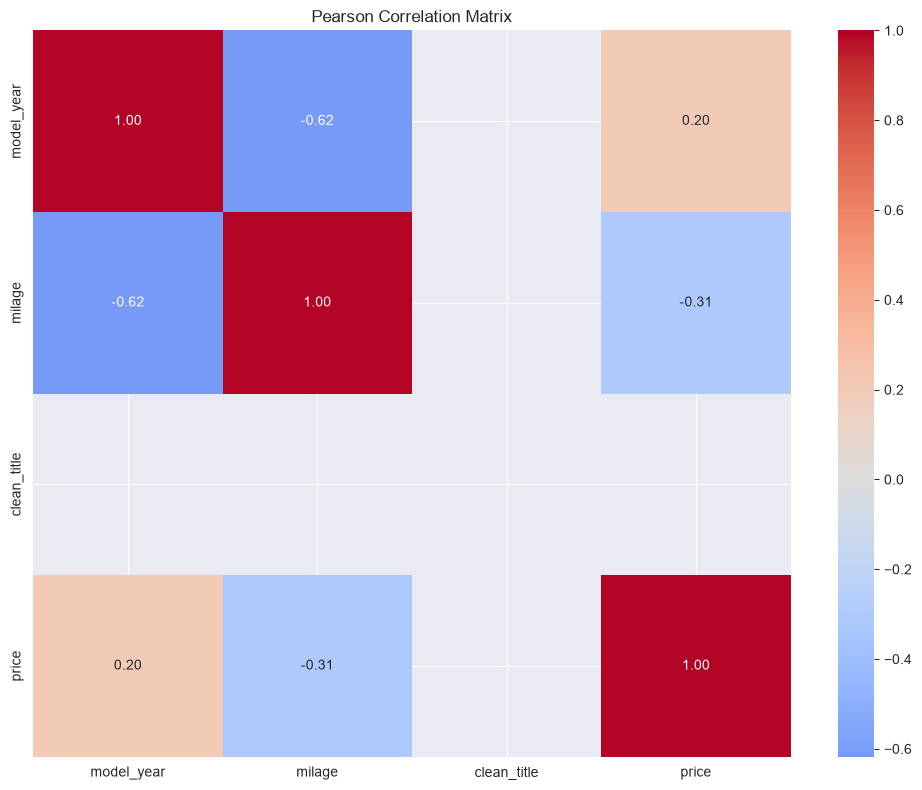


Feature correlation with target 'price' (ranked by |corr|):
milage        -0.306
model_year     0.199
clean_title      NaN
Name: price, dtype: float64
{'corr_matrix':              model_year    milage  clean_title     price
model_year     1.000000 -0.617720          NaN  0.199496
milage        -0.617720  1.000000          NaN -0.305528
clean_title         NaN       NaN          NaN       NaN
price          0.199496 -0.305528          NaN  1.000000, 'multicollinear_pairs': [], 'target_corr_ranked': milage        -0.305528
model_year     0.199496
clean_title         NaN
Name: price, dtype: float64}


In [31]:
def correlation_Analysis(df: pd.DataFrame, task_type: str = None, target_col: str = None, threshold: float = 0.85):
    numerical_column = numerical_col = df.select_dtypes(include=["number", "float", "int64"]).columns.tolist()
    if len(numerical_column) < 2:
        print("Not enough numerical columns to compute correlations")
        return None
    corr_matrix = df[numerical_col].corr(method="pearson")
    # ── Heatmap ──────────────────────────────────────────────────────────
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Pearson Correlation Matrix")
    plt.tight_layout()
    plt.show()
    # Multicollineraity
    multicollinear_pairs = []
    for i in range(len(numerical_column)):
        for j in range(i+1, len(numerical_column)):
            col_a, col_b = numerical_column[i], numerical_column[j]
            corr = corr_matrix.loc[col_a, col_b]
            if abs(corr) > threshold:
                multicollinear_pairs.append({
                    "col_a": col_a,
                    "col_b": col_b,
                    "corr": corr
                })
    if multicollinear_pairs:
        print(f"Total Multicollinear pairs: {len(multicollinear_pairs)}")
        for pair in multicollinear_pairs:
            print(f"Correlation between {pair["col_a"]} and {pair["col_b"]} is {pair["corr"]}")
    # ── Target correlation ranking (supervised tasks only) ──────────────────
    target_corr_ranked = None
    if task_type in ("Regression", "Classification") and target_col is not None:
        if target_col not in numerical_col:
            print(f"Target column '{target_col}' is not numeric — skipping target correlation ranking")
        else:
            target_corr = corr_matrix[target_col].drop(index=target_col)
            target_corr_ranked = target_corr.reindex(
                target_corr.abs().sort_values(ascending=False).index
            )
            print(f"\nFeature correlation with target '{target_col}' (ranked by |corr|):")
            print(target_corr_ranked.round(3))

    return {
        "corr_matrix": corr_matrix,
        "multicollinear_pairs": multicollinear_pairs,
        "target_corr_ranked": target_corr_ranked
    }
print(correlation_Analysis(cleaned_df, "Regression", "price"))

# PreProcessing

In [32]:
cleaned_df.columns

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='str')

In [33]:
target_col = "price"
print(target_col in cleaned_df.columns)

True


In [36]:
import json


def load_eda_summary(eda_summary_path: str = "../artifacts/eda/eda_summary.json") -> dict:
    path = Path(eda_summary_path)
    if not path.exists():
        raise FileNotFoundError(f"File '{eda_summary_path}' does not exist")
    with open(eda_summary_path) as f:
        eda_summary = json.load(f)
    print(f"EDA summary loaded from {path.resolve()}")
    return  eda_summary
eda_summary = load_eda_summary()
print(eda_summary)

FileNotFoundError: File '../artifacts/eda/eda_summary.json' does not exist

In [35]:
# Step 1 — Train-Test Split
def split_data(df: pd.DataFrame, target_col: str = None, task_type: str = None, test_size: float = 0.2, random_state: int = 42):
    df = df.copy()
    if task_type == "Clustering":
        x = df
        x_train, x_test = train_test_split(x, test_size=test_size, random_state=random_state)
        y_train, y_test = None, None
    else:
        if target_col is None or target_col not in df.columns:
            print(f"Error: Could not find target column '{target_col}' for {task_type}.")
            return None, None, None, None
        x = df.drop(columns=[target_col])
        y = df[target_col]
        if task_type == "Regression":
            x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=random_state)
        else:
            x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=random_state, stratify=y)
    print("--- Train-Test Split Completed ---")
    print(f"X_train shape: {x_train.shape} | X_test shape: {x_test.shape}")
    if y_train is not None:
        print(f"y_train shape: {y_train.shape} | y_test shape: {y_test.shape}")
    else:
        print("y_train: None | y_test: None (Clustering Task)")
    return x_train, x_test, y_train, y_test
x_train, x_test, y_train, y_test = split_data(cleaned_df, task_type="Regression", target_col="price")

--- Train-Test Split Completed ---
X_train shape: (3207, 11) | X_test shape: (802, 11)
y_train shape: (3207,) | y_test shape: (802,)


In [36]:
# Step 2 — Drop Quasi-Constant and Useless Columns
def drop_useless_columns(x_train, x_test, eda_summary):
    dropeed_column = [];
    quasi_constant = eda_summary.get("cardinality_report", {}).get("Flagged as Quasi-Constant! Consider dropping", [])
    if len(quasi_constant) == 0:
        print("No columns to drop.")
        return x_train, x_test, dropeed_column
    for col in quasi_constant:
        if col in x_train.columns:
            print(f"Dropping '{col}': Flagged as Quasi-Constant (almost zero variance).")
            dropeed_column.append(col)
    for col in x_train.columns:
        if x_train[col].nunique() == len(x_train):
            print(f"Dropping '{col}': Flagged as Unique Identifier (100% unique values).")
            dropeed_column.append(col)
    if dropeed_column > 0:
        x_train = x_train.drop(columns=dropeed_column, errors="ignore")
        x_test = x_test.drop(columns=dropeed_column, errors="ignore")
        print(f"\nSummary: Successfully dropped {len(dropeed_column)} useless columns.")
    else:
        print("Summary: No quasi-constant or unique ID columns found. Nothing dropped.")
    return x_train, x_test, dropeed_column
x_train, x_test, dropeed_column = drop_useless_columns(x_train, x_test, eda_summary=load_eda_summary())

EDA summary loaded from C:\Users\Shyam\PycharmProjects\AutoML\artifacts\eda\eda_summary.json
No columns to drop.


In [37]:
x_train.shape, x_test.shape

((3207, 11), (802, 11))

In [38]:
# Step 3 — Missing Value Imputation
def impute_missing_values(x_train, x_test, eda_summary):
    x_train = x_train.copy()
    x_test = x_test.copy()
    high_missing_cols = eda_summary.get("high_missing_cols", [])
    missing_value = eda_summary.get("missing_report", [])
    missing_columns = [item.get("Column") for item in missing_value]
    highly_skewed_cols = eda_summary.get("highly_skewed_cols", [])
    col_types = eda_summary.get("col_types", {})
    numerical_continuous = col_types.get("numerical_continuous", [])
    numerical_discrete = col_types.get("numerical_discrete", [])
    categorical_cols = col_types.get("categorical", [])
    boolean_cols = col_types.get("boolean", [])
    datetime_cols = col_types.get("datetime", [])
    numerical_cols = numerical_continuous + numerical_discrete
    fitted_imputers = {}
    for col in missing_columns:
        if col not in x_train.columns:
            continue
        imputer = None
        if col in datetime_cols:
            print(f"WARNING: Datetime column '{col}' has nulls. Do not impute here. Handle in feature engineering.")
            continue
        elif col in numerical_cols:
            if col in high_missing_cols:
                print(f"WARNING: Numerical column '{col}' has >30% missing values. Results may be unreliable. Imputing with median.")
                imputer = SimpleImputer(strategy='median')
            else:
                if col in highly_skewed_cols:
                    imputer = SimpleImputer(strategy='median')
                else:
                    imputer = SimpleImputer(strategy='mean')
        elif col in categorical_cols:
            imputer = SimpleImputer(strategy='most_frequent')
        elif col in boolean_cols:
            imputer = SimpleImputer(strategy='most_frequent')
        else:
            imputer = SimpleImputer(strategy='most_frequent')

        if imputer is not None:
            x_train[col] = imputer.fit_transform(x_train[[col]]).ravel()
            x_test[col] = imputer.transform(x_test[[col]]).ravel()
            fitted_imputers[col] = imputer
    return x_train, x_test, fitted_imputers

x_train, x_test, fitted_imputers = impute_missing_values(x_train, x_test, eda_summary=load_eda_summary())

EDA summary loaded from C:\Users\Shyam\PycharmProjects\AutoML\artifacts\eda\eda_summary.json


In [39]:
x_train.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title
2473,Ford,Explorer Platinum,2018,73049.0,Gasoline,3.5L V6 24V GDI DOHC Twin Turbo,6-Speed Automatic,Gray,Ebony Black,At least 1 accident or damage reported,1.0
1338,GMC,Yukon XL AT4,2023,9980.0,Gasoline,355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel,10-Speed A/T,Black,Black,None reported,1.0
1613,BMW,M3 Base,2016,55250.0,Gasoline,425.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,6-Speed M/T,Blue,White,None reported,1.0
1610,Lexus,IS 350 Base,2017,77300.0,Gasoline,306.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,6-Speed A/T,White,Black,None reported,1.0
2600,Ford,Focus SE,2018,33700.0,E85 Flex Fuel,160.0HP 2.0L 4 Cylinder Engine Flex Fuel Capab...,A/T,Gray,Black,At least 1 accident or damage reported,1.0


In [40]:
x_train.isnull().sum()

brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
dtype: int64

In [41]:
fitted_imputers

{'clean_title': SimpleImputer(strategy='most_frequent'),
 'fuel_type': SimpleImputer(strategy='most_frequent'),
 'accident': SimpleImputer(strategy='most_frequent')}

In [42]:
# Step 4 — Outlier Treatment (IQR Capping)
def cap_outliers(x_train, x_test, eda_summary):
    outlier_report = eda_summary.get("outlier_report", {})
    capping_bound = {}
    col = list(outlier_report.keys())
    for col, stats in outlier_report.items():
        if col in x_train.columns and stats.get("percentage", 0) > 0:
            q1, q3 = x_train[col].quantile(0.25), x_train[col].quantile(0.75)
            iqr = q3 - q1
            lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
            affected_rows = ((x_train[col] < lower) | (x_train[col] > upper)).sum()
            print(f"Capped '{col}' - bounds: ({lower:.2f}, {upper:.2f}) | Affected train rows: {affected_rows}")
            capping_bound[col] = (lower, upper)
            x_train[col] = x_train[col].clip(lower=lower, upper=upper)
            if col in x_test.columns:
                x_test[col] = x_test[col].clip(lower=lower, upper=upper)
    return x_train, x_test, capping_bound
x_train, x_test, capping_bound = cap_outliers(x_train, x_test, eda_summary=load_eda_summary())

EDA summary loaded from C:\Users\Shyam\PycharmProjects\AutoML\artifacts\eda\eda_summary.json
Capped 'model_year' - bounds: (2000.00, 2032.00) | Affected train rows: 52
Capped 'milage' - bounds: (-82679.50, 199984.50) | Affected train rows: 58


In [43]:
x_train.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title
2473,Ford,Explorer Platinum,2018,73049.0,Gasoline,3.5L V6 24V GDI DOHC Twin Turbo,6-Speed Automatic,Gray,Ebony Black,At least 1 accident or damage reported,1.0
1338,GMC,Yukon XL AT4,2023,9980.0,Gasoline,355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel,10-Speed A/T,Black,Black,None reported,1.0
1613,BMW,M3 Base,2016,55250.0,Gasoline,425.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,6-Speed M/T,Blue,White,None reported,1.0
1610,Lexus,IS 350 Base,2017,77300.0,Gasoline,306.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,6-Speed A/T,White,Black,None reported,1.0
2600,Ford,Focus SE,2018,33700.0,E85 Flex Fuel,160.0HP 2.0L 4 Cylinder Engine Flex Fuel Capab...,A/T,Gray,Black,At least 1 accident or damage reported,1.0


In [44]:
capping_bound

{'model_year': (np.float64(2000.0), np.float64(2032.0)),
 'milage': (np.float64(-82679.5), np.float64(199984.5))}

In [45]:
print(cleaned_df["fuel_type"].value_counts())

fuel_type
Gasoline          3309
Hybrid             194
E85 Flex Fuel      139
Diesel             116
–                   45
Plug-In Hybrid      34
not supported        2
Name: count, dtype: int64


In [46]:
eda_summary=load_eda_summary()
cardinality_report = eda_summary.get("cardinality_report", {})
lowCardinality = cardinality_report.get("Low Cardinality Prefer One Hot", [])
highCardinality = cardinality_report.get("High Cardinality Prefer Target / Feature Encoding", [])
cardinal_col = lowCardinality + highCardinality
for col in cardinal_col:
    print("-"*10, col, "-"*10)
    print(cleaned_df[col].value_counts())

EDA summary loaded from C:\Users\Shyam\PycharmProjects\AutoML\artifacts\eda\eda_summary.json
---------- fuel_type ----------
fuel_type
Gasoline          3309
Hybrid             194
E85 Flex Fuel      139
Diesel             116
–                   45
Plug-In Hybrid      34
not supported        2
Name: count, dtype: int64
---------- accident ----------
accident
None reported                             2910
At least 1 accident or damage reported     986
Name: count, dtype: int64
---------- brand ----------
brand
Ford             386
BMW              375
Mercedes-Benz    315
Chevrolet        292
Porsche          201
Audi             200
Toyota           199
Lexus            163
Jeep             143
Land             130
Nissan           116
Cadillac         107
GMC               91
RAM               91
Dodge             90
Tesla             87
Kia               76
Hyundai           72
Acura             64
Subaru            64
Mazda             64
Honda             63
INFINITI          59
V

In [47]:
from openai import OpenAI

def ai_group_column(series: pd.Series, col_name: str, client: OpenAI, min_unique: int = 7, max_unique: int = 300) -> dict | None:
    """
    Sends unique values of a column to OpenAI API.
    Returns a mapping dict {original_value: group_label} or None if it fails.
    """
    unique_vals = series.dropna().unique().tolist()

    # Skip if too few unique values (already clean) or too many (model/engine)
    if len(unique_vals) < min_unique or len(unique_vals) > max_unique:
        print(f"'{col_name}' skipped for AI grouping | unique count: {len(unique_vals)}")
        return None

    unique_vals_str = json.dumps(unique_vals[:150])  # cap to avoid token overflow

    prompt = f"""You are a data preprocessing expert.

Column name: "{col_name}"
Unique values: {unique_vals_str}

Group these values into meaningful semantic categories.
Rules:
- Create between 5 and 10 groups maximum
- Every value must be assigned to exactly one group
- Use clear, simple group names (e.g. "Black", "Automatic", "Gasoline")
- Unknown, missing, or ambiguous values → group as "Unknown"
- Return ONLY a valid JSON object mapping each original value to its group
- No explanation, no markdown, no extra text. Pure JSON only.

Example format:
{{"Jet Black": "Black", "Pearl White": "White", "–": "Unknown"}}"""

    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",        # cheap + smart enough for grouping tasks
            messages=[
                {
                    "role": "system",
                    "content": "You are a data preprocessing expert. You only return valid JSON. No markdown, no explanation."
                },
                {
                    "role": "user",
                    "content": prompt
                }
            ],
            temperature=0,              # 0 = deterministic, no creativity needed here
            max_tokens=2000,
            response_format={"type": "json_object"}   # forces valid JSON output
        )

        raw = response.choices[0].message.content.strip()
        mapping = json.loads(raw)
        print(f"'{col_name}' AI grouped | {len(unique_vals)} → {len(set(mapping.values()))} groups")
        return mapping

    except Exception as e:
        print(f"AI grouping failed for '{col_name}': {e}")
        return None

In [48]:
def decide_columns_for_ai_grouping(X_train: pd.DataFrame, eda_summary: dict,
                                    min_unique: int = 7,
                                    max_unique: int = 300) -> list:
    """
    Automatically decides which columns benefit from AI semantic grouping.
    Reads directly from eda_summary — no manual column list needed.

    A column is selected if:
    - It is categorical (object/category dtype)
    - Its unique count is between min_unique and max_unique
    - It is in high cardinality bucket (already flagged by EDA)
    """
    # ── Get high cardinality cols flagged by EDA ───────────────────
    high_cardinality_cols = eda_summary["cardinality_report"].get(
        "High Cardinality Prefer Target / Feature Encoding", []
    )

    # ── Also consider low-cardinality cols that still have ────────
    # ── enough unique values to benefit from grouping     ────────
    low_cardinality_cols = eda_summary["cardinality_report"].get(
        "Low Cardinality Prefer One Hot", []
    )

    candidates = []

    for col in X_train.columns:
        # Must be categorical dtype
        if X_train[col].dtype not in ["object", "category", "string"] and \
            not pd.api.types.is_string_dtype(X_train[col]):
                continue

        unique_count = X_train[col].nunique()

        # Must be within groupable range
        if unique_count < min_unique or unique_count > max_unique:
            print(
                f"'{col}' skipped for AI grouping | "
                f"unique count {unique_count} outside range [{min_unique}, {max_unique}]"
            )
            continue

        candidates.append(col)
        print(
            f"'{col}' selected for AI grouping | "
            f"unique count: {unique_count}"
        )

    print(
        f"AI grouping candidates: {candidates} | "
        f"total: {len(candidates)} columns"
    )
    return candidates

In [49]:
def apply_ai_grouping(X_train: pd.DataFrame, X_test: pd.DataFrame,
                      eda_summary: dict,
                      api_key: str) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    """
    Fully automated AI grouping — no manual column list needed.
    Decides which columns to group by reading eda_summary directly.
    """
    # ── Automatically decide which columns need grouping ───────────
    columns_to_group = decide_columns_for_ai_grouping(X_train, eda_summary)

    if not columns_to_group:
        print("No columns selected for AI grouping — skipping")
        return X_train, X_test, {}

    client = OpenAI(api_key=api_key)
    all_mappings = {}

    for col in columns_to_group:
        print(f"Running AI grouping on: '{col}'")
        mapping = ai_group_column(X_train[col], col, client)

        if mapping is None:
            print(f"'{col}' grouping returned None — keeping original values")
            continue

        # ── Validate mapping covers all unique values ──────────────
        original_vals = set(X_train[col].dropna().unique())
        mapped_vals   = set(mapping.keys())
        unmapped      = original_vals - mapped_vals
        if unmapped:
            print(
                f"'{col}' has {len(unmapped)} unmapped values → "
                f"defaulting to 'Unknown': {list(unmapped)[:10]}"
            )

        # ── Apply to both train and test ───────────────────────────
        X_train[col] = X_train[col].map(mapping).fillna("Unknown")
        X_test[col]  = X_test[col].map(mapping).fillna("Unknown")
        all_mappings[col] = mapping

        print(
            f"'{col}' grouped | "
            f"unique before: {len(original_vals)} → "
            f"unique after: {X_train[col].nunique()}"
        )

    print(
        f"AI grouping complete | "
        f"columns processed: {list(all_mappings.keys())}"
    )
    return x_train, x_test, all_mappings

In [50]:
import os
from dotenv import load_dotenv
load_dotenv()
api_key=os.getenv("OPENAI_API_KEY")
if api_key:
    X_train, X_test, ai_mappings = apply_ai_grouping(
        x_train, x_test, eda_summary, api_key   # ← no column list passed
    )
else:
    ai_mappings = {}
    print(
        "No API key — skipping AI grouping. "
        "High cardinality columns will use target/frequency encoding directly."
    )

'brand' selected for AI grouping | unique count: 56
'model' skipped for AI grouping | unique count 1634 outside range [7, 300]
'fuel_type' selected for AI grouping | unique count: 7
'engine' skipped for AI grouping | unique count 1038 outside range [7, 300]
'transmission' selected for AI grouping | unique count: 60
'ext_col' selected for AI grouping | unique count: 271
'int_col' selected for AI grouping | unique count: 135
'accident' skipped for AI grouping | unique count 2 outside range [7, 300]
AI grouping candidates: ['brand', 'fuel_type', 'transmission', 'ext_col', 'int_col'] | total: 5 columns
Running AI grouping on: 'brand'
'brand' AI grouped | 56 → 5 groups
'brand' grouped | unique before: 56 → unique after: 5
Running AI grouping on: 'fuel_type'
'fuel_type' AI grouped | 7 → 5 groups
'fuel_type' has 1 unmapped values → defaulting to 'Unknown': ['–']
'fuel_type' grouped | unique before: 7 → unique after: 5
Running AI grouping on: 'transmission'
'transmission' AI grouped | 60 → 3 g

In [51]:
x_train.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title
2473,American,Explorer Platinum,2018,73049.0,Gasoline,3.5L V6 24V GDI DOHC Twin Turbo,Automatic,Gray,Black,At least 1 accident or damage reported,1.0
1338,American,Yukon XL AT4,2023,9980.0,Gasoline,355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel,Automatic,Black,Black,None reported,1.0
1613,European,M3 Base,2016,55250.0,Gasoline,425.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,Manual,Blue,White,None reported,1.0
1610,Japanese,IS 350 Base,2017,77300.0,Gasoline,306.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,Automatic,White,Black,None reported,1.0
2600,American,Focus SE,2018,33700.0,Flex Fuel,160.0HP 2.0L 4 Cylinder Engine Flex Fuel Capab...,Automatic,Gray,Black,At least 1 accident or damage reported,1.0


In [52]:
eda_summary=load_eda_summary()
cardinality_report = eda_summary.get("cardinality_report", {})
lowCardinality = cardinality_report.get("Low Cardinality Prefer One Hot", [])
highCardinality = cardinality_report.get("High Cardinality Prefer Target / Feature Encoding", [])
cardinal_col = lowCardinality + highCardinality
for col in cardinal_col:
    print("-"*10, col, "-"*10)
    print(X_train[col].value_counts())

EDA summary loaded from C:\Users\Shyam\PycharmProjects\AutoML\artifacts\eda\eda_summary.json
---------- fuel_type ----------
fuel_type
Gasoline     2770
Hybrid        188
Flex Fuel     117
Diesel         95
Unknown        37
Name: count, dtype: int64
---------- accident ----------
accident
None reported                             2423
At least 1 accident or damage reported     784
Name: count, dtype: int64
---------- brand ----------
brand
European    1249
American    1173
Japanese     640
Korean       143
Swedish        2
Name: count, dtype: int64
---------- model ----------
model
M3 Base                                         23
Corvette Base                                   18
F-150 XLT                                       17
Wrangler Sport                                  16
911 Carrera                                     16
                                                ..
Rover Range Rover Sport Supercharged Dynamic     1
Lucerne CXL                                      1
15

In [53]:
from sklearn.model_selection import KFold
# Step 5 — Categorical Encoding
def target_encode_column(X_train: pd.DataFrame, X_test: pd.DataFrame,
                         col: str, y_train: pd.Series,
                         n_splits: int = 5,
                         smoothing: float = 10.0) -> tuple:
    """
    Out-of-fold target encoding — no leakage.
    Each row in X_train is encoded using target stats from OTHER folds only.
    X_test is encoded using full X_train stats.
    """
    X_train = X_train.copy()
    X_test  = X_test.copy()

    global_mean  = float(y_train.mean())
    oof_encoded  = np.zeros(len(X_train))
    kf           = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    # ── Out-of-fold encoding for X_train ──────────────────────────
    for train_idx, val_idx in kf.split(X_train):
        fold_X_tr  = X_train[col].iloc[train_idx]
        fold_y_tr  = y_train.iloc[train_idx]
        fold_X_val = X_train[col].iloc[val_idx]

        stats    = fold_y_tr.groupby(fold_X_tr).agg(["count", "mean"])
        smoothed = (
            (stats["count"] * stats["mean"] + smoothing * global_mean)
            / (stats["count"] + smoothing)
        )
        oof_encoded[val_idx] = (
            fold_X_val.map(smoothed).fillna(global_mean).values
        )

    # ── Full-train mapping for X_test ─────────────────────────────
    # Must be computed BEFORE overwriting X_train[col] with numbers
    full_stats    = y_train.groupby(X_train[col]).agg(["count", "mean"])
    full_smoothed = (
        (full_stats["count"] * full_stats["mean"] + smoothing * global_mean)
        / (full_stats["count"] + smoothing)
    )

    # ── Apply ─────────────────────────────────────────────────────
    X_train[col] = oof_encoded
    X_test[col]  = X_test[col].map(full_smoothed).fillna(global_mean)

    encoding_map = full_smoothed.to_dict()
    encoding_map["__global_mean__"] = global_mean

    return X_train, X_test, encoding_map

In [54]:
def encode_categoricals(x_train: pd.DataFrame, x_test: pd.DataFrame,
                        eda_summary: dict, target_col: str,
                        y_train: pd.Series, task_type: str):
    x_train = x_train.copy()
    x_test = x_test.copy()
    fitted_encoders = {}
    datetime_cols = eda_summary.get("column_types", {}).get("datetime", [])
    boolean_cols  = eda_summary.get("column_types", {}).get("boolean", [])
    categorical_col = x_train.select_dtypes(include=["object", "category", "string"]).columns.tolist()
    for col in categorical_col:
        if col in datetime_cols:
            print(f"'{col}' skipped — datetime, handled in feature extraction")
            continue
        if col in boolean_cols:
            print(f"'{col}' skipped — boolean, already encoded")
            continue
        # Edge case: If a column is completely empty, skip it to avoid errors
        if x_train[col].dropna().empty:
            continue
        unique_count = x_train[col].nunique()
        print(f"Encoding '{col}' | unique values: {unique_count}")
        if unique_count <= 30:
            ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first")
            # Reset index before concat to avoid NaN misalignment
            x_train = x_train.reset_index(drop=True)
            x_test  = x_test.reset_index(drop=True)
            train_encoded = ohe.fit_transform(x_train[[col]])
            test_encoded = ohe.transform(x_test[[col]])
            feature_name = ohe.get_feature_names_out([col])
            train_encoded_df = pd.DataFrame(train_encoded, columns=feature_name, index=x_train.index)
            test_encoded_df = pd.DataFrame(test_encoded, columns=feature_name, index=x_test.index)
            x_train = pd.concat([x_train.drop(columns=[col]), train_encoded_df], axis=1)
            x_test = pd.concat([x_test.drop(columns=[col]), test_encoded_df], axis=1)
            fitted_encoders[col] = {"type": "ohe", "encoder": ohe}
            print(f"  → OneHot | created {len(feature_name)} columns")
        else:
            if task_type == "Clustering":
                # frequency encoding
                freq_map = (x_train[col].value_counts(normalize=True)).to_dict()
                x_train[col] = x_train[col].map(freq_map).fillna(0)
                x_test[col] = x_test[col].map(freq_map).fillna(0)
                fitted_encoders[col] = {
                    "type": "frequency",
                    "map": freq_map
                }
                print(f"  → Frequency Encoding | {unique_count} → numeric")
            else:
                # Target Encoding
                x_train, x_test, enc_map = target_encode_column(
                    x_train, x_test, col, y_train
                )
                fitted_encoders[col] = {
                    "type": "target",
                    "map": enc_map
                }
                print(f"  → Target Encoding (OOF) | {unique_count} → numeric")
    print(f"\nEncoding complete | columns encoded: {len(fitted_encoders)}")
    print(f"  OHE columns    : {[c for c,v in fitted_encoders.items() if v['type']=='ohe']}")
    print(f"  Target encoded : {[c for c,v in fitted_encoders.items() if v['type']=='target']}")
    print(f"  Freq encoded   : {[c for c,v in fitted_encoders.items() if v['type']=='frequency']}")

    return x_train, x_test, fitted_encoders

In [55]:
x_train, x_test, fitted_encoders = encode_categoricals(
    x_train, x_test,
    eda_summary=eda_summary,
    target_col=eda_summary.get("task_type"),
    y_train=y_train,
    task_type=eda_summary.get("task_type")
)
print(x_train.shape)
print(x_train.dtypes)
print(f"Fitted Column {fitted_encoders.keys()}")

Encoding 'brand' | unique values: 5
  → OneHot | created 4 columns
Encoding 'model' | unique values: 1634
  → Target Encoding (OOF) | 1634 → numeric
Encoding 'fuel_type' | unique values: 5
  → OneHot | created 4 columns
Encoding 'engine' | unique values: 1038
  → Target Encoding (OOF) | 1038 → numeric
Encoding 'transmission' | unique values: 3
  → OneHot | created 2 columns
Encoding 'ext_col' | unique values: 10
  → OneHot | created 9 columns
Encoding 'int_col' | unique values: 13
  → OneHot | created 12 columns
Encoding 'accident' | unique values: 2
  → OneHot | created 1 columns

Encoding complete | columns encoded: 8
  OHE columns    : ['brand', 'fuel_type', 'transmission', 'ext_col', 'int_col', 'accident']
  Target encoded : ['model', 'engine']
  Freq encoded   : []
(3207, 37)
model                     float64
model_year                  int64
milage                    float64
engine                    float64
clean_title               float64
brand_European            float64
bran

C:\Users\Shyam\PycharmProjects\AutoML\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [56]:
x_train.head()

,model,model_year,milage,engine,clean_title,brand_European,brand_Japanese,brand_Korean,brand_Swedish,fuel_type_Flex Fuel,...,int_col_Gold,int_col_Gray,int_col_Green,int_col_Orange,int_col_Red,int_col_Silver,int_col_Unknown,int_col_White,int_col_Yellow,accident_None reported
0,41932.506165,2018,73049.0,37296.463985,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,43125.756782,2023,9980.0,45640.046112,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,50812.628391,2016,55250.0,37843.771188,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,44888.130652,2017,77300.0,41167.371188,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,60479.797318,2018,33700.0,43125.756782,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [57]:
# Step 6 — Datetime Feature Extraction
def extract_datetime_features(x_train, x_test, eda_summary):
    dataTimeCol = eda_summary.get("column_types", {}).get("datetime", [])
    x_train = x_train.copy()
    x_test = x_test.copy()
    for col in dataTimeCol:
        if col in x_train.columns:
            x_train[col] = pd.to_datetime(x_train[col], errors="coerce")
            x_train[f'{col}_year'] = x_train[col].dt.year
            x_train[f'{col}_month'] = x_train[col].dt.month
            x_train[f'{col}_day'] = x_train[col].dt.day
            x_train[f'{col}_dayofweek'] = x_train[col].dt.dayofweek
            x_train[f'{col}_is_weekend'] = (x_train[f'{col}_dayofweek'] >= 5).astype(int)
        if col in x_test.columns:
            x_test[col] = pd.to_datetime(x_test[col], errors='coerce')
            x_test[f'{col}_year'] = x_test[col].dt.year
            x_test[f'{col}_month'] = x_test[col].dt.month
            x_test[f'{col}_day'] = x_test[col].dt.day
            x_test[f'{col}_dayofweek'] = x_test[col].dt.dayofweek
            x_test[f'{col}_is_weekend'] = (x_test[f'{col}_dayofweek'] >= 5).astype(int)
        x_train = x_train.drop(columns=[col])
        if col in x_test.columns:
            x_test = x_test.drop(columns=[col])
    return x_train, x_test

In [58]:
x_train, x_test = extract_datetime_features(x_train, x_test, eda_summary=load_eda_summary())
print(x_train.shape, x_test.shape)

EDA summary loaded from C:\Users\Shyam\PycharmProjects\AutoML\artifacts\eda\eda_summary.json
(3207, 37) (802, 37)


In [59]:
x_train.head()

,model,model_year,milage,engine,clean_title,brand_European,brand_Japanese,brand_Korean,brand_Swedish,fuel_type_Flex Fuel,...,int_col_Gold,int_col_Gray,int_col_Green,int_col_Orange,int_col_Red,int_col_Silver,int_col_Unknown,int_col_White,int_col_Yellow,accident_None reported
0,41932.506165,2018,73049.0,37296.463985,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,43125.756782,2023,9980.0,45640.046112,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,50812.628391,2016,55250.0,37843.771188,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,44888.130652,2017,77300.0,41167.371188,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,60479.797318,2018,33700.0,43125.756782,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [60]:
print(x_train.columns.tolist())
print(x_train.columns[x_train.columns.duplicated()])

['model', 'model_year', 'milage', 'engine', 'clean_title', 'brand_European', 'brand_Japanese', 'brand_Korean', 'brand_Swedish', 'fuel_type_Flex Fuel', 'fuel_type_Gasoline', 'fuel_type_Hybrid', 'fuel_type_Unknown', 'transmission_Manual', 'transmission_Unknown', 'ext_col_Blue', 'ext_col_Color', 'ext_col_Gray', 'ext_col_Green', 'ext_col_Neutral', 'ext_col_Red', 'ext_col_Silver', 'ext_col_Unknown', 'ext_col_White', 'int_col_Black', 'int_col_Blue', 'int_col_Brown', 'int_col_Gold', 'int_col_Gray', 'int_col_Green', 'int_col_Orange', 'int_col_Red', 'int_col_Silver', 'int_col_Unknown', 'int_col_White', 'int_col_Yellow', 'accident_None reported']
Index([], dtype='str')


In [61]:
# Step 7 — Feature Scaling
def scale_features(x_train, x_test, eda_summary):
    # 1. Safely identify column types
    highly_skewed_cols = eda_summary.get("highly_skewed_cols", [])
    column_types = eda_summary.get("column_types", {})
    all_numerical = column_types.get("numerical_continuous", []) + column_types.get("numerical_discrete", [])

    # Store original columns and index to reconstruct the DataFrame later
    train_cols = x_train.columns.tolist()

    # Filter columns to ensure we only process what is actually inside x_train
    highly_skewed_cols = [col for col in highly_skewed_cols if col in train_cols]
    normal_skew_cols = [col for col in all_numerical if col not in highly_skewed_cols and col in train_cols]

    # Identify the remainder (categorical/boolean columns that pass through untouched)
    passthrough_cols = [col for col in train_cols if col not in highly_skewed_cols and col not in normal_skew_cols]

    # 2. Determine the EXACT output order of the ColumnTransformer
    output_col_order = highly_skewed_cols + normal_skew_cols + passthrough_cols

    # 3. Create the Transformers
    skewed_pipeline = Pipeline(steps=[
        ('log1p', FunctionTransformer(np.log1p, validate=False)),
        ('minmax', MinMaxScaler())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('skewed', skewed_pipeline, highly_skewed_cols),
            ('normal', StandardScaler(), normal_skew_cols)
        ],
        remainder='passthrough'
    )

    # 4. Fit and Transform
    x_train_transformed = preprocessor.fit_transform(x_train)
    x_test_transformed = preprocessor.transform(x_test)

    # THE FIX: Force the output into a raw, nameless NumPy array to prevent Pandas from creating NaNs
    x_train_raw_array = np.asarray(x_train_transformed)
    x_test_raw_array = np.asarray(x_test_transformed)

    # 5. Manually rebuild the Pandas DataFrames
    x_train_scaled = pd.DataFrame(
        x_train_raw_array,
        columns=output_col_order,
        index=x_train.index
    )
    x_test_scaled = pd.DataFrame(
        x_test_raw_array,
        columns=output_col_order,
        index=x_test.index
    )

    # 6. Restore the exact original column order
    x_train_scaled = x_train_scaled[train_cols]
    x_test_scaled = x_test_scaled[train_cols]

    return x_train_scaled, x_test_scaled, preprocessor
x_train, x_test, processor = scale_features(x_train, x_test, eda_summary=load_eda_summary())

EDA summary loaded from C:\Users\Shyam\PycharmProjects\AutoML\artifacts\eda\eda_summary.json


In [62]:
x_train.columns

Index(['model', 'model_year', 'milage', 'engine', 'clean_title',
       'brand_European', 'brand_Japanese', 'brand_Korean', 'brand_Swedish',
       'fuel_type_Flex Fuel', 'fuel_type_Gasoline', 'fuel_type_Hybrid',
       'fuel_type_Unknown', 'transmission_Manual', 'transmission_Unknown',
       'ext_col_Blue', 'ext_col_Color', 'ext_col_Gray', 'ext_col_Green',
       'ext_col_Neutral', 'ext_col_Red', 'ext_col_Silver', 'ext_col_Unknown',
       'ext_col_White', 'int_col_Black', 'int_col_Blue', 'int_col_Brown',
       'int_col_Gold', 'int_col_Gray', 'int_col_Green', 'int_col_Orange',
       'int_col_Red', 'int_col_Silver', 'int_col_Unknown', 'int_col_White',
       'int_col_Yellow', 'accident_None reported'],
      dtype='str')

In [63]:
processor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('skewed', ...), ('normal', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``f

In [64]:
x_train.head()

,model,model_year,milage,engine,clean_title,brand_European,brand_Japanese,brand_Korean,brand_Swedish,fuel_type_Flex Fuel,...,int_col_Gold,int_col_Gray,int_col_Green,int_col_Orange,int_col_Red,int_col_Silver,int_col_Unknown,int_col_White,int_col_Yellow,accident_None reported
0,41932.506165,0.751116,0.867328,37296.463985,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,43125.756782,0.958571,0.605110,45640.046112,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,50812.628391,0.667990,0.830539,37843.771188,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,44888.130652,0.709563,0.874779,41167.371188,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,60479.797318,0.751116,0.765414,43125.756782,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [65]:
# Step 8 — Handle Class Imbalance (Classification Only)
def handle_class_imbalance(x_train, y_train, eda_summary, task_type):
    task_type = eda_summary.get("task_type")
    if task_type != "Classification":
        print(f"Skipping class imbalance — task is {task_type}")
        return x_train, y_train
    target_analysis = eda_summary.get("target_analysis", {})
    is_imbalanced = target_analysis.get("is_imbalanced", False)
    if not is_imbalanced:
        print("Classes are balanced — no resampling needed")
        return x_train, y_train
    imbalance_ratio = target_analysis.get("imbalance_ratio", 1.0)
    print(f"Class imbalance detected | ratio: {imbalance_ratio:.2f}")
    print(f"Class distribution before resampling:\n{y_train.value_counts()}")
    if imbalance_ratio <= 10:
        # Use Smote
        from imblearn.over_sampling import SMOTE
        smote = SMOTE(random_state=42)
        strategy = "SMOTE"
    else:
        from imblearn.combine import SMOTETomek
        sample = SMOTETomek(random_state=42)
        strategy = "SMOTETomek"
    x_train_res, y_train_res = sample.fit_resample(x_train, y_train)
    print(f"Strategy used: {strategy}")
    print(f"Class distribution after resampling:\n{y_train_res.value_counts()}")
    print(f"Shape before: {x_train.shape} → after: {x_train_res.shape}")
    return x_train_res, y_train_res
x_train, y_train = handle_class_imbalance(x_train, y_train, eda_summary=load_eda_summary(), task_type=eda_summary.get("task_type"))

EDA summary loaded from C:\Users\Shyam\PycharmProjects\AutoML\artifacts\eda\eda_summary.json
Skipping class imbalance — task is Regression


In [66]:
x_train.shape

(3207, 37)

In [67]:
x_train.shape

(3207, 37)

In [68]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [69]:

def calac_vif(data):
    clean_data = data.select_dtypes(include=['number', 'bool']).dropna(axis=1, how='all')
    clean_data = clean_data.astype(float).fillna(0)
    X = add_constant(clean_data)

    vif_df = pd.DataFrame()
    vif_df['Variable'] = X.columns
    vif_df['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    return vif_df[vif_df['Variable'] != 'const'].sort_values(by='VIF', ascending=False)

vif_result = calac_vif(x_train)
print(vif_result)

C:\Users\Shyam\PycharmProjects\AutoML\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


                  Variable       VIF
11      fuel_type_Gasoline  4.264891
12        fuel_type_Hybrid  2.986807
25           int_col_Black  2.457942
10     fuel_type_Flex Fuel  2.177644
2               model_year  2.000223
3                   milage  1.772574
29            int_col_Gray  1.747759
24           ext_col_White  1.537106
13       fuel_type_Unknown  1.491799
6           brand_European  1.399939
18            ext_col_Gray  1.354837
7           brand_Japanese  1.350557
22          ext_col_Silver  1.311795
27           int_col_Brown  1.295182
16            ext_col_Blue  1.286922
32             int_col_Red  1.262748
34         int_col_Unknown  1.261113
35           int_col_White  1.239703
21             ext_col_Red  1.230572
23         ext_col_Unknown  1.214371
14     transmission_Manual  1.180548
4                   engine  1.151750
17           ext_col_Color  1.150606
19           ext_col_Green  1.121651
8             brand_Korean  1.115799
1                    model  1.114677
3

In [70]:
import pandas as pd
import numpy as np
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

def remove_high_vif_features(x_train, x_test, threshold=10.0):
    x_train = x_train.copy()
    x_test = x_test.copy()

    numerical_col = x_train.select_dtypes(include=["number", "int64", "float64", "float"]).columns.tolist()
    dropped_features = []

    while True:
        if len(numerical_col) == 0:
            break

        # 1. Add the constant for correct math
        x_calc = add_constant(x_train[numerical_col])
        vif_data = []

        # 2. Iterate through columns, skipping the 'const' column we just added
        for i in range(x_calc.shape[1]):
            col_name = x_calc.columns[i]
            if col_name == 'const':
                continue

            vif_score = variance_inflation_factor(x_calc.values, i)
            vif_data.append((col_name, vif_score))

        # Sort by highest VIF
        vif_data.sort(key=lambda x: x[1], reverse=True)
        max_col, max_vif = vif_data[0]

        # 3. Handle the NaN warning (Constant columns like clean_title)
        if pd.isna(max_vif):
            print(f"Dropping '{max_col}' | VIF Score: NaN (Zero variance / Constant column)")
            numerical_col.remove(max_col)
            dropped_features.append(max_col)
            x_train = x_train.drop(columns=[max_col])
            x_test = x_test.drop(columns=[max_col])
            continue # Restart the loop

        # 4. Standard threshold check
        if max_vif > threshold:
            print(f"Dropping '{max_col}' | VIF Score: {max_vif:.2f}")
            numerical_col.remove(max_col)
            dropped_features.append(max_col)

            x_train = x_train.drop(columns=[max_col])
            x_test = x_test.drop(columns=[max_col])
        else:
            break
    print(vif_data)

    print(f"\nTotal features dropped due to multicollinearity: {len(dropped_features)}")
    return x_train, x_test, dropped_features

# Run the fixed pipeline step
x_train, x_test, dropped_features = remove_high_vif_features(x_train, x_test, threshold=10.0)

C:\Users\Shyam\PycharmProjects\AutoML\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


Dropping 'clean_title' | VIF Score: NaN (Zero variance / Constant column)
[('fuel_type_Gasoline', np.float64(4.264890543118672)), ('fuel_type_Hybrid', np.float64(2.986807195009743)), ('int_col_Black', np.float64(2.4579418019584907)), ('fuel_type_Flex Fuel', np.float64(2.177643633380667)), ('model_year', np.float64(2.000222739352186)), ('milage', np.float64(1.7725739710772475)), ('int_col_Gray', np.float64(1.7477594213808636)), ('ext_col_White', np.float64(1.537106014728621)), ('fuel_type_Unknown', np.float64(1.4917994992488368)), ('brand_European', np.float64(1.3999393046012925)), ('ext_col_Gray', np.float64(1.3548366798950349)), ('brand_Japanese', np.float64(1.3505569399710284)), ('ext_col_Silver', np.float64(1.3117947543445674)), ('int_col_Brown', np.float64(1.2951822002594662)), ('ext_col_Blue', np.float64(1.2869217628607719)), ('int_col_Red', np.float64(1.2627481959868732)), ('int_col_Unknown', np.float64(1.2611130799780126)), ('int_col_White', np.float64(1.2397034937037734)), ('ex

In [71]:
x_train.columns

Index(['model', 'model_year', 'milage', 'engine', 'brand_European',
       'brand_Japanese', 'brand_Korean', 'brand_Swedish',
       'fuel_type_Flex Fuel', 'fuel_type_Gasoline', 'fuel_type_Hybrid',
       'fuel_type_Unknown', 'transmission_Manual', 'transmission_Unknown',
       'ext_col_Blue', 'ext_col_Color', 'ext_col_Gray', 'ext_col_Green',
       'ext_col_Neutral', 'ext_col_Red', 'ext_col_Silver', 'ext_col_Unknown',
       'ext_col_White', 'int_col_Black', 'int_col_Blue', 'int_col_Brown',
       'int_col_Gold', 'int_col_Gray', 'int_col_Green', 'int_col_Orange',
       'int_col_Red', 'int_col_Silver', 'int_col_Unknown', 'int_col_White',
       'int_col_Yellow', 'accident_None reported'],
      dtype='str')

# Feature Engineering

In [72]:
# Step 1
def generate_polynomial_features(x_train, x_test, eda_summary, degree=2,max_cols=10):
    candidates = eda_summary.get("column_types", {}).get("numerical_continuous", [])
    candidates = [col for col in candidates if col in x_train.columns]
    # Check minimum requirements
    if len(candidates) < 2:
        print(f"Skipping PolynomialFeatures: Found {len(candidates)} valid continuous columns (need at least 2).")
        return x_train, x_test, None
    variances = x_train[candidates].var()
    top_cols = variances.sort_values(ascending=False).head(max_cols).index.tolist()
    print(f"Generating polynomial features (degree={degree}) for {len(top_cols)} high-variance continuous columns...")
    poly = PolynomialFeatures(degree=degree, interaction_only=False, include_bias=False)
    # fit on x_train and transform on x_test
    x_train_poly_arrr = poly.fit_transform(x_train[top_cols])
    x_test_poly_arrr = poly.transform(x_test[top_cols])
    new_feature_names = poly.get_feature_names_out(top_cols)
    # Reconstructing the dataset
    x_train_poly_df = pd.DataFrame(x_train_poly_arrr, columns=new_feature_names, index=x_train.index)
    x_test_poly_df = pd.DataFrame(x_test_poly_arrr, columns=new_feature_names, index=x_test.index)
    # we need to drop the original columns from X_train/X_test before merging the new ones in.
    x_train_dropped = x_train.drop(columns=top_cols)
    x_test_dropped = x_test.drop(columns=top_cols)
    x_train_final = pd.concat([x_train_dropped, x_train_poly_df], axis=1)
    x_test_final = pd.concat([x_test_dropped, x_test_poly_df], axis=1)
    new_cols_count = len(new_feature_names) - len(top_cols) # subtract the original columns to get the net *new* count
    print(f"Successfully created {new_cols_count} new polynomial/interaction features.")
    print(f"Old X_train shape: {X_train.shape} | New X_train shape: {x_train_final.shape}")
    return x_train_final, x_test_final, poly
x_train, x_test, poly = generate_polynomial_features(x_train, x_test, eda_summary=load_eda_summary())

EDA summary loaded from C:\Users\Shyam\PycharmProjects\AutoML\artifacts\eda\eda_summary.json
Generating polynomial features (degree=2) for 2 high-variance continuous columns...
Successfully created 3 new polynomial/interaction features.
Old X_train shape: (3207, 11) | New X_train shape: (3207, 39)


In [73]:
# Step 2 — AI-Based Derived Feature Generation
def generate_ai_derived_features(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    eda_summary: dict,
    task_type: str,
    target_col: str,
    api_key: str,
    max_features: int = 5
) -> tuple[pd.DataFrame, pd.DataFrame, list]:
    """
    Uses OpenAI GPT to analyze the dataset context and derive new meaningful
    features by combining existing columns. AI decides:
        1. Whether feature derivation is even needed for this dataset
        2. Which columns to combine
        3. What mathematical operation to apply
        4. Why the new feature is meaningful (domain reasoning)

    Only derives features if AI determines it will help. Skips if dataset
    doesn't benefit. Caps at max_features to avoid noise.

    Args:
        X_train      : Training features (post-preprocessing, post-polynomial)
        X_test       : Test features
        eda_summary  : Full EDA summary dict (provides context to AI)
        task_type    : "Regression" | "Classification" | "Clustering"
        target_col   : Name of the target column (None for Clustering)
        api_key      : OpenAI API key
        max_features : Hard cap on number of new features AI can derive

    Returns:
        X_train      : DataFrame with new columns appended (if any)
        X_test       : DataFrame with same new columns appended
        derived_cols : List of new column names created (empty if AI skips)
    """
    import json
    from openai import OpenAI

    print("STEP 2 — AI-Based Derived Feature Generation")

    if not api_key:
        print("No OpenAI API key provided — skipping AI feature derivation")
        return X_train, X_test, []

    # ── Build context snapshot for AI ─────────────────────────────────────────
    # Give AI only what it needs: column names, types, stats, task context.
    # Sending full data would blow the token limit and leak row-level info.

    numerical_cols = (
        eda_summary.get("column_types", {}).get("numerical_continuous", []) +
        eda_summary.get("column_types", {}).get("numerical_discrete", [])
    )
    categorical_cols = eda_summary.get("column_types", {}).get("categorical", [])

    # Filter to only columns that actually exist in X_train right now
    # (some may have been dropped by preprocessing or polynomial step)
    available_numerical = [c for c in numerical_cols if c in X_train.columns]
    available_categorical = [c for c in categorical_cols if c in X_train.columns]
    all_available = X_train.columns.tolist()

    # Build a compact stats snapshot — mean, std, min, max for numericals
    stats_snapshot = {}
    for col in available_numerical[:20]:  # cap at 20 to avoid token overflow
        stats_snapshot[col] = {
            "mean":   round(float(X_train[col].mean()), 4),
            "std":    round(float(X_train[col].std()), 4),
            "min":    round(float(X_train[col].min()), 4),
            "max":    round(float(X_train[col].max()), 4),
        }

    # Sample top categories for categorical columns
    cat_snapshot = {}
    for col in available_categorical[:10]:
        top_vals = X_train[col].value_counts().head(5).index.tolist()
        cat_snapshot[col] = top_vals

    context = {
        "task_type": task_type,
        "target_column": target_col,
        "all_columns": all_available[:50],           # cap to avoid token overflow
        "numerical_columns": available_numerical[:20],
        "categorical_columns": available_categorical[:10],
        "numerical_stats": stats_snapshot,
        "categorical_top_values": cat_snapshot,
        "n_rows": eda_summary.get("n_rows"),
        "highly_skewed_cols": eda_summary.get("highly_skewed_cols", []),
        "multicollinear_pairs": eda_summary.get("correlation", {}).get("multicollinear_pairs", [])[:5],
        "target_corr_ranked": eda_summary.get("correlation", {}).get("target_corr_ranked", {})
    }

    # ── Build the prompt ───────────────────────────────────────────────────────
    prompt = f"""You are a senior data scientist and domain expert reviewing a dataset for a machine learning pipeline.

DATASET CONTEXT:
{json.dumps(context, indent=2)}

YOUR TASK:
Analyze the dataset and decide whether deriving new features by combining existing columns would meaningfully improve model performance.

RULES:
1. Only suggest a feature if it has clear domain logic — not just mathematical combinations.
2. Only use columns that exist in "all_columns" list above.
3. Each feature must be derivable using basic math: +, -, *, /, log, ratio, difference, or a conditional.
4. Maximum {max_features} features total. Fewer is better — only suggest if genuinely useful.
5. If the dataset does not benefit from derived features (e.g. already clean tabular data with clear independent columns), return an empty list.
6. Never combine a column with itself.
7. The formula must be executable as a pandas expression using column names.
8. For classification/regression: prioritize features that likely correlate with the target.
9. For clustering: prioritize features that capture meaningful group differences.

RESPONSE FORMAT — return ONLY a valid JSON object, no markdown, no explanation:

{{
  "should_derive": true or false,
  "reason": "one sentence explaining your decision",
  "features": [
    {{
      "name": "new_column_name",
      "formula": "col_a / (col_b + 1e-8)",
      "columns_used": ["col_a", "col_b"],
      "domain_reason": "brief explanation of why this combination is meaningful"
    }}
  ]
}}

If should_derive is false, return an empty features list.
Column names in formula must exactly match names in "all_columns".
Use 1e-8 in denominators to avoid division by zero."""

    # ── Call OpenAI API ────────────────────────────────────────────────────────
    try:
        client = OpenAI(api_key=api_key)
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {
                    "role": "system",
                    "content": (
                        "You are a data science expert. "
                        "You return only valid JSON. No markdown, no explanation outside the JSON."
                    )
                },
                {
                    "role": "user",
                    "content": prompt
                }
            ],
            temperature=0,                                    # deterministic
            max_tokens=1000,
            response_format={"type": "json_object"}          # force valid JSON
        )

        raw = response.choices[0].message.content.strip()
        result = json.loads(raw)

    except Exception as e:
        print(f"OpenAI API call failed for feature derivation: {e}")
        return X_train, X_test, []

    # ── Parse AI response ──────────────────────────────────────────────────────
    should_derive = result.get("should_derive", False)
    reason = result.get("reason", "")
    features = result.get("features", [])

    print(f"AI decision — should_derive: {should_derive} | reason: {reason}")

    if not should_derive or not features:
        print("AI determined no derived features are needed for this dataset — skipping")
        return X_train, X_test, []

    # ── Apply each derived feature ─────────────────────────────────────────────
    X_train = X_train.copy()
    X_test = X_test.copy()
    derived_cols = []

    for feature_spec in features[:max_features]:            # hard cap enforcement
        name = feature_spec.get("name", "").strip()
        formula = feature_spec.get("formula", "").strip()
        cols_used = feature_spec.get("columns_used", [])
        domain_reason = feature_spec.get("domain_reason", "")

        # ── Validate before applying ───────────────────────────────────────────
        if not name or not formula:
            print(f"Skipping feature — missing name or formula: {feature_spec}")
            continue

        # Check all required columns exist in X_train
        missing_cols = [c for c in cols_used if c not in X_train.columns]
        if missing_cols:
            print(
                f"Skipping '{name}' — columns not found in X_train: {missing_cols}"
            )
            continue

        # Check name doesn't clash with existing column
        if name in X_train.columns:
            print(f"Skipping '{name}' — column already exists")
            continue

        # ── Apply formula safely using eval ───────────────────────────────────
        # We use a restricted namespace: only the DataFrame columns + numpy.
        # This prevents arbitrary code execution from the AI response.
        try:
            namespace = {col: X_train[col] for col in X_train.columns}
            namespace["np"] = __import__("numpy")

            train_values = eval(formula, {"__builtins__": {}}, namespace)

            # Validate output is numeric and same length as X_train
            train_series = pd.to_numeric(pd.Series(train_values, index=X_train.index), errors="coerce")

            if train_series.isna().mean() > 0.5:
                print(
                    f"Skipping '{name}' — formula produced >50% NaN values "
                    f"(formula may be invalid: {formula})"
                )
                continue

            # Apply same formula to X_test
            test_namespace = {col: X_test[col] for col in X_test.columns}
            test_namespace["np"] = __import__("numpy")
            test_values = eval(formula, {"__builtins__": {}}, test_namespace)
            test_series = pd.to_numeric(pd.Series(test_values, index=X_test.index), errors="coerce")

            # Fill any NaN in new feature with train median (safe for test too)
            fill_val = float(train_series.median())
            train_series = train_series.fillna(fill_val)
            test_series = test_series.fillna(fill_val)

            # Append to DataFrames
            X_train[name] = train_series
            X_test[name] = test_series
            derived_cols.append(name)

            print(
                f"Created '{name}' | formula: {formula} | "
                f"reason: {domain_reason} | "
                f"train NaN after fill: {X_train[name].isna().sum()}"
            )

        except Exception as e:
            print(f"Failed to apply formula for '{name}': {formula} | error: {e}")
            continue

    print(
        f"AI feature derivation complete | "
        f"requested: {len(features)} | "
        f"successfully created: {len(derived_cols)} | "
        f"columns: {derived_cols}"
    )

    return X_train, X_test, derived_cols
x_train, x_test, derived_cols = generate_ai_derived_features(x_train, x_test, eda_summary=load_eda_summary(), task_type=eda_summary.get("task_type"), target_col=eda_summary.get("target_col"), api_key=api_key)

EDA summary loaded from C:\Users\Shyam\PycharmProjects\AutoML\artifacts\eda\eda_summary.json
STEP 2 — AI-Based Derived Feature Generation
AI decision — should_derive: True | reason: Deriving new features can capture interactions between existing variables that may improve model performance.
Created 'model_year_milage_ratio' | formula: model_year / (milage + 1e-8) | reason: The ratio of model year to milage may indicate the age of the vehicle relative to its usage, which can influence price. | train NaN after fill: 0
Created 'milage_squared' | formula: milage * milage | reason: The square of milage can capture non-linear effects of usage on price. | train NaN after fill: 0
AI feature derivation complete | requested: 2 | successfully created: 2 | columns: ['model_year_milage_ratio', 'milage_squared']


In [74]:
derived_cols

['model_year_milage_ratio', 'milage_squared']

In [75]:
# Step 3
def generate_interaction_features(x_train, x_test, eda_summary, task_type):
    if task_type == "Clustering":
        print("Skipping Aggregate Features: Task type is Clustering.")
        return x_train,x_test,[]
    categorial_col = eda_summary.get("column_types", {}).get("categorical", [])
    categorial_col = [col for col in categorial_col if col in x_train.columns]
    numerical_cont = eda_summary.get("column_types", {}).get("numerical_continuous", [])
    numerical_cont = [col for col in numerical_cont if col in x_train.columns]
    if not categorial_col or not numerical_cont:
        print("Skipping Aggregate Features: Missing categorical or numerical columns.")
        return x_train,x_test,[]
    new_col_names = []
    for cat_col in categorial_col:
        if x_train[cat_col].nunique() > 30:
            continue
        for num_col in numerical_cont:
            print(f"Creating aggregate features for: {cat_col} -> {num_col}")
            group_stats = x_train.groupby(cat_col)[num_col].agg(['mean', 'std', 'min', 'max', 'count'])
            global_mean = x_train[num_col].mean()
            global_std = 0
            for stat in ['mean', 'std', 'min', 'max', 'count']:
                new_col_name = f"{cat_col}_{num_col}_{stat}"
                stat_lookup = group_stats[stat].to_dict()
                x_train[new_col_name] = x_train[cat_col].map(stat_lookup)
                x_test[new_col_name] = x_test[cat_col].map(stat_lookup)
                fill_value = global_std if stat == 'std' else global_mean
                if stat == 'count': fill_value = 0
                x_train[new_col_name] = x_train[new_col_name].fillna(fill_value)
                x_test[new_col_name] = x_test[new_col_name].fillna(fill_value)
                new_col_names.append(new_col_name)
    if len(new_col_names) > 50:
        print(f"Capping aggregate features: Dropping {len(new_col_names) - 50} excess columns.")
        columns_to_drop = new_col_names[50:]
        x_train = x_train.drop(columns=columns_to_drop)
        x_test = x_test.drop(columns=columns_to_drop)
        new_col_names = new_col_names[:50]
        print(f"Successfully created {len(new_col_names)} aggregate features.")
    return x_train, x_test, new_col_names
x_train, x_test, new_col_names = generate_interaction_features(x_train, x_test, eda_summary=load_eda_summary(), task_type=eda_summary.get("task_type"))

EDA summary loaded from C:\Users\Shyam\PycharmProjects\AutoML\artifacts\eda\eda_summary.json


In [76]:
x_train.shape

(3207, 41)

In [77]:
# Step 4 — select_features_variance
def select_features_variance(x_train, x_test, threshold=0.01):
    selector = VarianceThreshold(threshold=threshold)
    selector.fit(x_train)
    # get_support() returns an array like: [True, False, False, True]
    kept_mask = selector.get_support()
    removed_cols = x_train.columns[~kept_mask].tolist()
    kept_cols = x_train.columns[kept_mask].tolist()
    # Log removed columns and their variance scores
    print("Dropped columns and their variances:")
    for idx, col in enumerate(x_train.columns):
        if not kept_mask[idx]:
            # selector.variances_ holds the variance for every original feature
            variance_score = selector.variances_[idx]
            print(f" - {col}: {variance_score:.6f}")
    # transform return numpy array
    x_train_arr = selector.transform(x_train)
    x_test_arr = selector.transform(x_test)
    x_train_df = pd.DataFrame(x_train_arr, columns=kept_cols, index=x_train.index)
    x_test_df = pd.DataFrame(x_test_arr, columns=kept_cols, index=x_test.index)
    print(f"Removed col: {removed_cols}")
    print(f"\nOriginal X_train shape: {x_train.shape}")
    print(f"New X_train shape: {x_train_df.shape}")
    return x_train_df, x_test_df, removed_cols
x_train, x_test, removed_columns = select_features_variance(x_train, x_test)
print(removed_columns)

Dropped columns and their variances:
 - brand_Swedish: 0.000623
 - transmission_Unknown: 0.004964
 - int_col_Blue: 0.008961
 - int_col_Gold: 0.002488
 - int_col_Green: 0.002178
 - int_col_Orange: 0.005581
 - int_col_Silver: 0.004037
 - int_col_Yellow: 0.000312
Removed col: ['brand_Swedish', 'transmission_Unknown', 'int_col_Blue', 'int_col_Gold', 'int_col_Green', 'int_col_Orange', 'int_col_Silver', 'int_col_Yellow']

Original X_train shape: (3207, 41)
New X_train shape: (3207, 33)
['brand_Swedish', 'transmission_Unknown', 'int_col_Blue', 'int_col_Gold', 'int_col_Green', 'int_col_Orange', 'int_col_Silver', 'int_col_Yellow']


In [78]:
x_train.columns

Index(['model', 'engine', 'brand_European', 'brand_Japanese', 'brand_Korean',
       'fuel_type_Flex Fuel', 'fuel_type_Gasoline', 'fuel_type_Hybrid',
       'fuel_type_Unknown', 'transmission_Manual', 'ext_col_Blue',
       'ext_col_Color', 'ext_col_Gray', 'ext_col_Green', 'ext_col_Neutral',
       'ext_col_Red', 'ext_col_Silver', 'ext_col_Unknown', 'ext_col_White',
       'int_col_Black', 'int_col_Brown', 'int_col_Gray', 'int_col_Red',
       'int_col_Unknown', 'int_col_White', 'accident_None reported',
       'model_year', 'milage', 'model_year^2', 'model_year milage', 'milage^2',
       'model_year_milage_ratio', 'milage_squared'],
      dtype='str')

In [79]:
# Step 5 — select_features_univariate
def select_features_univariate(x_train, x_test, y_train, task_type, k="all"):
    if task_type == "Clustering":
        print("Skipping Univariate Selection: Task type is Clustering (no target variable).")
        return x_train, x_test, list(x_train.columns)
    if task_type == "Regression":
        score_function = f_regression
    elif task_type == "Classification":
        score_function = f_classif
    else:
        print(f"Error: Unknown task type '{task_type}'. Skipping selection.")
        return X_train, X_test, list(X_train.columns)
    selector = SelectKBest(score_function, k=k)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        selector.fit(x_train, y_train)
    # (If a feature has perfectly 0 variance, sklearn sets its score to NaN. We fill those with 0).
    scores = np.nan_to_num(selector.scores_, nan=0.0)
    pvalues = np.nan_to_num(selector.pvalues_, nan=1.0)
    stats_df = pd.DataFrame({
        'Feature': x_train.columns,
        'Score': scores,
        'P_Value': pvalues
    })
    bottom_20 = stats_df.sort_values(by='Score', ascending=True).head(20)
    print("\n--- Bottom 20 Weakest Features ---")
    print(bottom_20.to_string(index=False))
    insignificant = stats_df[stats_df['P_Value'] > 0.05]
    if not insignificant.empty:
        print(f"\nFlagged {len(insignificant)} features with p-value > 0.05 (Statistically Insignificant).")
    selected_cols = selector.get_feature_names_out(x_train.columns)
    x_train_selected = pd.DataFrame(selector.transform(x_train), columns=selected_cols, index=x_train.index)
    x_test_selected = pd.DataFrame(selector.transform(x_test), columns=selected_cols, index=x_test.index)
    dropped_count = len(X_train.columns) - len(selected_cols)
    if dropped_count > 0:
        print(f"\nSummary: Successfully dropped {dropped_count} lowest-scoring features.")
    else:
        print("\nSummary: Evaluated all features, none dropped (k='all').")
    return x_train_selected, x_test_selected, selected_cols
x_train, x_test, selected_cols = select_features_univariate(x_train, x_test, y_train, task_type=eda_summary.get("task_type"))
print(selected_cols)


--- Bottom 20 Weakest Features ---
                Feature     Score  P_Value
     fuel_type_Gasoline  0.071796 0.788756
      fuel_type_Unknown  0.086670 0.768473
          ext_col_Color  0.092771 0.760704
model_year_milage_ratio  0.143171 0.705174
           ext_col_Gray  0.152477 0.696205
           ext_col_Blue  0.190192 0.662786
          ext_col_Green  0.329798 0.565818
            ext_col_Red  0.535536 0.464342
                  model  0.909150 0.340412
          ext_col_White  0.915399 0.338758
                 engine  1.225540 0.268359
        ext_col_Neutral  3.683380 0.055046
      model_year milage  3.843413 0.050028
          int_col_Black  4.452633 0.034925
       fuel_type_Hybrid  5.552984 0.018509
          int_col_Brown  7.247011 0.007139
          int_col_White  7.497006 0.006214
    transmission_Manual  7.791278 0.005281
         ext_col_Silver 11.572809 0.000677
        int_col_Unknown 13.096833 0.000300

Flagged 13 features with p-value > 0.05 (Statistically Insig

In [80]:
import pandas as pd
from sklearn.ensemble import ExtraTreesClassifier, ExtraTreesRegressor
from sklearn.feature_selection import SelectFromModel

def select_features_model_based(x_train, x_test, y_train, task_type, threshold='median'):
    if task_type == "Clustering":
        return x_train, x_test, list(x_train.columns)

    # FIX 1: ExtraTrees (Plural)
    if task_type == "Regression":
        estimator = ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    elif task_type == "Classification":
        estimator = ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    else:
        print(f"Error: Unknown task type '{task_type}'. Skipping selection.")
        return x_train, x_test, list(x_train.columns)

    selector = SelectFromModel(estimator=estimator, threshold=threshold)
    selector.fit(x_train, y_train)

    importance = selector.estimator_.feature_importances_
    kept_mask = selector.get_support()

    importance_df = pd.DataFrame({
        'Feature': x_train.columns,
        'Importance': importance,
        'Kept': kept_mask
    }).sort_values(by='Importance', ascending=False)

    # FIX 2: Matched 'Kept' (Capital K)
    kept_cols = importance_df[importance_df['Kept']]['Feature'].tolist()
    dropped_cols = importance_df[~importance_df['Kept']]['Feature'].tolist()

    print("\n--- Top 10 Most Important Features (ExtraTrees) ---")
    print(importance_df.head(10).to_string(index=False))
    print(f"\nSummary: Kept {len(kept_cols)} features, Dropped {len(dropped_cols)} features.")

    # FIX 3: Matched x_train and x_test (lowercase x)
    x_train_selected = pd.DataFrame(
        selector.transform(x_train),
        columns=kept_cols,
        index=x_train.index
    )
    x_test_selected = pd.DataFrame(
        selector.transform(x_test),
        columns=kept_cols,
        index=x_test.index
    )

    return x_train_selected, x_test_selected, kept_cols

# Execution
x_train, x_test, kept_cols = select_features_model_based(
    x_train, x_test, y_train, task_type=eda_summary.get("task_type")
)


--- Top 10 Most Important Features (ExtraTrees) ---
                Feature  Importance  Kept
               milage^2    0.146692  True
                 milage    0.120341  True
         milage_squared    0.116461  True
         brand_European    0.094732  True
           model_year^2    0.055536  True
      model_year milage    0.054030  True
             model_year    0.053519  True
model_year_milage_ratio    0.041155  True
                 engine    0.040443  True
                  model    0.037027  True

Summary: Kept 17 features, Dropped 16 features.


In [81]:
x_train.shape

(3207, 17)

In [82]:
# Step 7 — select_features_rfe
def select_features_rfe(x_train, x_test, y_train, task_type, n_features_to_select=None):
    if task_type == "Clustering":
        print("Skipping RFE Selection: Task type is Clustering (no target variable).")
        return x_train, x_train, list(x_train.columns)
    if x_train.shape[1] > 50:
        print(f"Error: Too many features to select ({n_features_to_select}).")
        return x_train, x_train, list(x_train.columns)
    if task_type == "Regression":
        estimator = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
        metric = 'r2'
    elif task_type == "Classification":
        estimator = LogisticRegression(max_iter=200, random_state=42)
        metric = 'f1_weighted'
    else:
        print(f"Error: Unknown task type '{task_type}'. Skipping selection.")
        return x_train, x_train, list(x_train.columns)
    selector = RFECV(estimator=estimator, step=1, cv=5, scoring=metric)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        selector.fit(x_train, y_train)
    kept_mask = selector.get_support()
    kept_cols = x_train.columns[kept_mask].tolist()
    eliminated_cols = x_train.columns[~kept_mask].tolist()
    print(f"\nOptimal number of features found by CV: {selector.n_features_}")
    print(f"Eliminated {len(eliminated_cols)} features:")
    # Print the dropped features so the user/logs can see exactly what RFE thought was useless
    if eliminated_cols:
        print(", ".join(eliminated_cols))
    else:
        print("None")
    x_train_selected = pd.DataFrame(
        selector.transform(x_train),
        columns=kept_cols,
        index=x_train.index
    )
    x_test_selected = pd.DataFrame(
        selector.transform(x_test),
        columns=kept_cols,
        index=x_test.index
    )
    return x_train_selected, x_test_selected, kept_cols
x_train, x_test, kept_cols = select_features_rfe(x_train, x_test, y_train, task_type=eda_summary.get("task_type"))
print(kept_cols)


Optimal number of features found by CV: 13
Eliminated 4 features:
brand_European, model_year milage, model_year, engine
['milage^2', 'milage', 'milage_squared', 'model_year^2', 'model_year_milage_ratio', 'model', 'ext_col_Unknown', 'fuel_type_Unknown', 'ext_col_Silver', 'int_col_Black', 'int_col_Unknown', 'fuel_type_Gasoline', 'ext_col_Blue']


In [83]:
x_train.shape

(3207, 13)

# Model Registry

In [90]:
try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False
    print.warning("XGBoost is not installed. 'xgboost' will be excluded from the model registry.")

try:
    from lightgbm import LGBMRegressor
    HAS_LIGHTGBM = True
except ImportError:
    HAS_LIGHTGBM = False
    print.warning("LightGBM is not installed. 'lightgbm' will be excluded from the model registry.")

In [91]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Lasso, ElasticNet
# Step 1 — _build_regression_models

def _build_regression_models() -> dict:
    registry = {
        "ridge": {
            "model": Ridge(alpha=1.0),
            "name": "Ridge Regression",
            "type": "linear",
            "supports_shap": True,
            "handles_nan": False,
            "tags": ["fast", "interpretable", "baseline"]
        },
        "lasso": {
            "model": Lasso(alpha=0.01, max_iter=5000),
            "name": "Lasso Regression",
            "type": "linear",
            "supports_shap": True,
            "handles_nan": False,
            "tags": ["fast", "interpretable", "feature_selection"]
        },
        "elastic_net": {
            "model": ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=5000),
            "name": "Elastic Net",
            "type": "linear",
            "supports_shap": True,
            "handles_nan": False,
            "tags": ["fast", "interpretable", "regularized"]
        },
        "random_forest": {
            "model": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
            "name": "Random Forest",
            "type": "ensemble",
            "supports_shap": True,
            "handles_nan": False,
            "tags": ["strong baseline", "tree_based", "robust"]
        },
        "extra_trees": {
            "model": ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
            "name": "Extra Trees",
            "type": "ensemble",
            "supports_shap": True,
            "handles_nan": False,
            "tags": ["fast", "tree_based", "handles_noise"]
        },
        "gradient_boosting": {
            "model": GradientBoostingRegressor(n_estimators=100, random_state=42),
            "name": "Gradient Boosting",
            "type": "ensemble",
            "supports_shap": True,
            "handles_nan": False,
            "tags": ["strong", "tree_based", "sequential"]
        }
    }
    if HAS_XGBOOST:
        registry["xgboost"] = {
            "model": XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbosity=0),
            "name": "XGBoost",
            "type": "ensemble",
            "supports_shap": True,
            "handles_nan": True,
            "tags": ["fast", "tree_based", "handles_missing", "gradient_boosting"]
        }
    if HAS_LIGHTGBM:
        registry["lightgbm"] = {
            "model": LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1),
            "name": "LightGBM",
            "type": "ensemble",
            "supports_shap": True,
            "handles_nan": True,
            "tags": ["fastest", "tree_based", "large_data", "handles_missing"]
        }
    return registry

In [129]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import RidgeClassifier


# Step 2 — _build_classification_models
def _build_classification_models() -> dict:
    registry = {
        "logistic_regression": {
            "model": LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
            "name": "Logistic Regression",
            "type": "linear",
            "supports_shap": True,
            "handles_nan": False,
            "supports_predict_proba": True,
            "tags": ["fast", "interpretable", "probability_output", "baseline"]
        },
        "ridge_classifier": {
            "model": RidgeClassifier(),
            "name": "Ridge Classifier",
            "type": "linear",
            "supports_shap": True,
            "handles_nan": False,
            "supports_predict_proba": False,  # Critical: No predict_proba support
            "tags": ["fast", "interpretable", "many_class"]
        },
        "random_forest": {
            "model": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
            "name": "Random Forest",
            "type": "ensemble",
            "supports_shap": True,
            "handles_nan": False,
            "supports_predict_proba": True,
            "tags": ["strong baseline", "tree_based", "robust"]
        },
        "extra_trees": {
            "model": ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1),
            "name": "Extra Trees",
            "type": "ensemble",
            "supports_shap": True,
            "handles_nan": False,
            "supports_predict_proba": True,
            "tags": ["fast", "tree_based", "less_overfit"]
        },
        "gradient_boosting": {
            "model": GradientBoostingClassifier(n_estimators=100, random_state=42),
            "name": "Gradient Boosting",
            "type": "ensemble",
            "supports_shap": True,
            "handles_nan": False,
            "supports_predict_proba": True,
            "tags": ["strong", "tree_based", "imbalanced_data"]
        },
        "knn": {
            "model": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
            "name": "K-Nearest Neighbors",
            "type": "neighbor",
            "supports_shap": True,  # Via KernelExplainer
            "handles_nan": False,
            "supports_predict_proba": True,
            "tags": ["non_parametric", "lazy_evaluation", "distance_based"]
        }
    }

    if HAS_XGBOOST:
        registry["xgboost"] = {
            "model": XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbosity=0, eval_metric="logloss"),
            "name": "XGBoost",
            "type": "ensemble",
            "supports_shap": True,
            "handles_nan": True,
            "supports_predict_proba": True,
            "tags": ["fast", "tree_based", "handles_missing", "native_multiclass"]
        }

    if HAS_LIGHTGBM:
        registry["lightgbm"] = {
            "model": LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1),
            "name": "LightGBM",
            "type": "ensemble",
            "supports_shap": True,
            "handles_nan": True,
            "supports_predict_proba": True,
            "tags": ["fastest", "tree_based", "large_data", "handles_missing"]
        }
    return registry

In [93]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering


# Step 3 — _build_clustering_models
def _build_clustering_models() -> dict:
    registry = {
        "kmeans": {
            "model": KMeans(n_clusters=8, random_state=42, n_init=10),
            "name": "K-Means",
            "type": "clustering",
            "needs_n_clusters": True,
            "supports_predict": True,
            "hpo_param": "n_clusters",
            "tags": ["workhorse", "centroid_based", "distance_based"]
        },
        "minibatch_kmeans": {
            "model": MiniBatchKMeans(n_clusters=8, random_state=42, n_init=10),
            "name": "Mini-Batch K-Means",
            "type": "clustering",
            "needs_n_clusters": True,
            "supports_predict": True,
            "hpo_param": "n_clusters",
            "tags": ["fast", "large_data", "centroid_based"]
        },
        "agglomerative": {
            "model": AgglomerativeClustering(n_clusters=8),
            "name": "Agglomerative Clustering",
            "type": "clustering",
            "needs_n_clusters": True,
            "supports_predict": False,
            "hpo_param": "n_clusters",
            "tags": ["hierarchical", "bottom_up", "no_random_state"]
        },
        "gmm": {
            "model": GaussianMixture(n_components=8, random_state=42),
            "name": "Gaussian Mixture Model",
            "type": "clustering",
            "needs_n_clusters": True,
            "supports_predict": True,
            "hpo_param": "n_components",
            "tags": ["soft_clustering", "probabilistic", "bic_selection"]
        },
        "dbscan": {
            "model": DBSCAN(eps=0.5, min_samples=5),
            "name": "DBSCAN",
            "type": "clustering",
            "needs_n_clusters": False,
            "supports_predict": False,
            "hpo_param": "eps",
            "returns_noise_label": True,
            "tags": ["density_based", "arbitrary_shapes", "auto_n_clusters"]
        },
        "spectral": {
            "model": SpectralClustering(n_clusters=8, random_state=42, n_jobs=-1),
            "name": "Spectral Clustering",
            "type": "clustering",
            "needs_n_clusters": True,
            "supports_predict": False,  # Only has fit_predict()
            "hpo_param": "n_clusters",
            "max_rows_recommended": 5000, # Critical guardrail for O(N^3) time / O(N^2) memory complexity
            "tags": ["graph_based", "non_convex", "manifold"]
        }
    }
    return registry

In [94]:
# Step 4 — _build_regression_search_spaces
def _build_regression_search_spaces():
    hyperparameter = {
        "ridge": [
            {"name": "alpha", "type": "float", "low": 1e-3, "high": 1e3, "log": True}
        ],
        "lasso": [
            {"name": "alpha", "type": "float", "low": 1e-4, "high": 10, "log": True},
            {"name": "max_iter", "type": "int", "low": 1000, "high": 10000}
        ],
        "elastic_net": [
            {"name": "alpha", "type": "float", "low": 1e-4, "high": 10, "log": True},
            {"name": "l1_ratio", "type": "float", "low": 0.01, "high": 0.99}
        ],
        "random_forest": [
            {"name": "n_estimators", "type": "int", "low": 50, "high": 500},
            {"name": "max_depth", "type": "int", "low": 3, "high": 20},
            {"name": "min_samples_split", "type": "int", "low": 2, "high": 20},
            {"name": "min_samples_leaf", "type": "int", "low": 1, "high": 10},
            {"name": "max_features", "type": "categorical", "choices": ["sqrt", "log2", 0.5, 0.7, 1.0]}
        ],
        "extra_trees": [
            {"name": "n_estimators", "type": "int", "low": 50, "high": 500},
            {"name": "max_depth", "type": "int", "low": 3, "high": 20},
            {"name": "min_samples_split", "type": "int", "low": 2, "high": 20},
            {"name": "min_samples_leaf", "type": "int", "low": 1, "high": 10},
            {"name": "max_features", "type": "categorical", "choices": ["sqrt", "log2", 0.5, 0.7, 1.0]}
        ],
        "gradient_boosting": [
            {"name": "n_estimators", "type": "int", "low": 50, "high": 500},
            {"name": "max_depth", "type": "int", "low": 3, "high": 20},
            {"name": "learning_rate", "type": "float", "low": 1e-3, "high": 0.3, "log": True},
            {"name": "subsample", "type": "float", "low": 0.5, "high": 1.0},
            {"name": "min_samples_leaf", "type": "int", "low": 1, "high": 10}
        ],
        "xgboost": [
            {"name": "n_estimators", "type": "int", "low": 50, "high": 500},
            {"name": "max_depth", "type": "int", "low": 3, "high": 20},
            {"name": "learning_rate", "type": "float", "low": 1e-3, "high": 0.3, "log": True},
            {"name": "subsample", "type": "float", "low": 0.5, "high": 1.0},
            {"name": "colsample_bytree", "type": "float", "low": 0.4, "high": 1.0},
            {"name": "reg_alpha", "type": "float", "low": 1e-8, "high": 10, "log": True},
            {"name": "reg_lambda", "type": "float", "low": 1e-8, "high": 10, "log": True}
        ],
        "lightgbm": [
            {"name": "n_estimators", "type": "int", "low": 50, "high": 500},
            {"name": "max_depth", "type": "int", "low": 3, "high": 20},
            {"name": "learning_rate", "type": "float", "low": 1e-3, "high": 0.3, "log": True},
            {"name": "num_leaves", "type": "int", "low": 20, "high": 300},
            {"name": "subsample", "type": "float", "low": 0.5, "high": 1.0},
            {"name": "colsample_bytree", "type": "float", "low": 0.4, "high": 1.0},
            {"name": "reg_alpha", "type": "float", "low": 1e-8, "high": 10, "log": True},
            {"name": "reg_lambda", "type": "float", "low": 1e-8, "high": 10, "log": True}
        ]
    }
    return hyperparameter

In [95]:
# Step 5 — _build_classification_search_spaces
def _get_shared_tree_spaces() -> dict:
    hyperparameter = {
        "random_forest": [
            {"name": "n_estimators", "type": "int", "low": 50, "high": 500},
            {"name": "max_depth", "type": "int", "low": 3, "high": 20},
            {"name": "min_samples_split", "type": "int", "low": 2, "high": 20},
            {"name": "min_samples_leaf", "type": "int", "low": 1, "high": 10},
            {"name": "max_features", "type": "categorical", "choices": ["sqrt", "log2", 0.5, 0.7, 1.0]}
        ],
        "extra_trees": [
            {"name": "n_estimators", "type": "int", "low": 50, "high": 500},
            {"name": "max_depth", "type": "int", "low": 3, "high": 20},
            {"name": "min_samples_split", "type": "int", "low": 2, "high": 20},
            {"name": "min_samples_leaf", "type": "int", "low": 1, "high": 10},
            {"name": "max_features", "type": "categorical", "choices": ["sqrt", "log2", 0.5, 0.7, 1.0]}
        ],
        "gradient_boosting": [
            {"name": "n_estimators", "type": "int", "low": 50, "high": 500},
            {"name": "max_depth", "type": "int", "low": 3, "high": 20},
            {"name": "learning_rate", "type": "float", "low": 1e-3, "high": 0.3, "log": True},
            {"name": "subsample", "type": "float", "low": 0.5, "high": 1.0},
            {"name": "min_samples_leaf", "type": "int", "low": 1, "high": 10}
        ],
        "xgboost": [
            {"name": "n_estimators", "type": "int", "low": 50, "high": 500},
            {"name": "max_depth", "type": "int", "low": 3, "high": 20},
            {"name": "learning_rate", "type": "float", "low": 1e-3, "high": 0.3, "log": True},
            {"name": "subsample", "type": "float", "low": 0.5, "high": 1.0},
            {"name": "colsample_bytree", "type": "float", "low": 0.4, "high": 1.0},
            {"name": "reg_alpha", "type": "float", "low": 1e-8, "high": 10, "log": True},
            {"name": "reg_lambda", "type": "float", "low": 1e-8, "high": 10, "log": True}
        ],
        "lightgbm": [
            {"name": "n_estimators", "type": "int", "low": 50, "high": 500},
            {"name": "max_depth", "type": "int", "low": 3, "high": 20},
            {"name": "learning_rate", "type": "float", "low": 1e-3, "high": 0.3, "log": True},
            {"name": "num_leaves", "type": "int", "low": 20, "high": 300},
            {"name": "subsample", "type": "float", "low": 0.5, "high": 1.0},
            {"name": "colsample_bytree", "type": "float", "low": 0.4, "high": 1.0},
            {"name": "reg_alpha", "type": "float", "low": 1e-8, "high": 10, "log": True},
            {"name": "reg_lambda", "type": "float", "low": 1e-8, "high": 10, "log": True}
        ]
    }
    return hyperparameter

In [96]:
def _build_classification_search_spaces() -> dict:
    params = _get_shared_tree_spaces()
    params['xgboost'].append(
        {"name": "scale_pos_weight", "type": "float", "low": 1.0, "high": 100.0}
    )
    params["lightgbm"].append(
        {"name": "is_unbalance", "type": "categorical", "choices": [True, False]}
    )
    params["logistic_regression"] = [
        {"name": "C", "type": "float", "low": 1e-4, "high": 100.0, "log": True},
        {"name": "solver", "type": "categorical", "choices": ["lbfgs", "saga"]},
        {"name": "penalty", "type": "categorical", "choices": ["l2", "l1", "elasticnet"]}
    ]
    params["ridge_classifier"] = [
        {"name": "alpha", "type": "float", "low": 1e-3, "high": 1e3, "log": True}
    ]
    params["knn"] = [
        {"name": "n_neighbors", "type": "int", "low": 1, "high": 50},
        {"name": "weights", "type": "categorical", "choices": ["uniform", "distance"]},
        {"name": "metric", "type": "categorical", "choices": ["euclidean", "manhattan", "minkowski"]}
    ]
    return params

In [97]:
# Step 6 — _build_clustering_search_spaces
def _build_clustering_search_spaces()->dict:
    params = {
      "kmeans": [
        {"name": "n_clusters", "type": "int", "low": 2, "high": 15}
      ],
      "minibatch_kmeans": [
        {"name": "n_clusters", "type": "int", "low": 2, "high": 15},
        {"name": "batch_size", "type": "int", "low": 100, "high": 1000}
      ],
      "agglomerative": [
        {"name": "n_clusters", "type": "int", "low": 2, "high": 15},
        {"name": "linkage",    "type": "categorical", "choices": ["ward", "complete", "average"]},
        {"ward_constraint": True}
      ],
      "gmm": [
        {"name": "n_components",    "type": "int",         "low": 2,   "high": 15},
        {"name": "covariance_type", "type": "categorical", "choices": ["full", "tied", "diag", "spherical"]}
      ],
      "dbscan": [
        {"name": "eps",         "type": "float", "low": 0.01, "high": 2.0},
        {"name": "min_samples", "type": "int",   "low": 2,    "high": 30}
      ],
      "spectral": [
        {"name": "n_clusters", "type": "int", "low": 2, "high": 15},
        {"name": "affinity",   "type": "categorical", "choices": ["rbf", "nearest_neighbors"]}
      ]
    }
    return params

In [115]:
# Step 7 — get_models
def get_models(task_type: str):
    normalized_task = task_type.strip().title()
    if normalized_task == "Regression":
        model = _build_regression_models()
    elif normalized_task == "Classification":
        model = _build_classification_models()
    elif normalized_task == "Clustering":
        model = _build_clustering_models()
    else:
        error_msg = f"Invalid task type: '{task_type}'. Valid options are: Regression, Classification, Clustering."
        # logging.error(error_msg)
        raise ValueError(error_msg)
    if not model:
        error_msg = f"Literally zero models survived for task type '{normalized_task}'. Check optional dependencies."
        # logging.critical(error_msg)
        raise ValueError(error_msg)
    return model

In [122]:
# Step 9 — get_model_instance
# def get_model_instance()

In [123]:
# Step 10 — get_scoring_metric
def get_scoring_metric(task_type: str):
    normalized_task = task_type.strip().title()
    metrics_map = {
        "Regression": ("neg_root_mean_squared_error", "minimize"),
        "Classification": ("f1_weighted", "maximize", "sklearn"),
        "Clustering": ("silhouette", "maximize", "custom")
    }
    if normalized_task not in metrics_map:
        valid_options = ", ".join(metrics_map.keys())
        error_msg = f"Invalid task_type: '{task_type}'. Valid options are: {valid_options}."
        # logger.error(error_msg)
        raise ValueError(error_msg)
    return metrics_map[normalized_task]

In [124]:
# Step 11 — get_all_model_keys
def get_all_model_keys(task_type: str):
    models_registry = get_models(task_type)
    valid_keys = []
    for model_key, model_defination in models_registry.items():
        if model_defination.get("model") is not None:
            valid_keys.append(model_key)
        else:
            # logger.debug(
            #     f"Excluding '{model_key}' from active training keys: "
            #     f"model object is None (likely due to a failed optional import)."
            # )
            print(
                f"Excluding '{model_key}' from active training keys: "
                f"model object is None (likely due to a failed optional import)."
            )
    if not valid_keys:
        # logger.critical(
        #     f"No valid models survived the import checks for task '{task_type}'. "
        #     f"The active training list is empty."
        # )
        print(
            f"No valid models survived the import checks for task '{task_type}'. "
            f"The active training list is empty."
        )
    return valid_keys

In [121]:
# Step 8 — get_search_space
def get_search_space(task_type: str, model_key: str):
    normalized_task = task_type.strip().title()
    search_space_builders = {
        "Regression": _build_regression_search_spaces,
        "Classification": _build_classification_search_spaces,
        "Clustering": _build_clustering_search_spaces,
    }
    if normalized_task not in search_space_builders:
        valid_options = ", ".join(search_space_builders.keys())
        error_msg = f"Invalid task_type: '{task_type}'. Valid options are: {valid_options}."
        # logger.error(error_msg)
        raise ValueError(error_msg)
    task_search_spaces = search_space_builders[normalized_task]()
    if model_key not in task_search_spaces:
        print(
            f"Model key '{model_key}' not found in {normalized_task} search spaces. "
            f"Returning empty list. (HPO will run with default parameters)."
        )
        return []
    return task_search_spaces[model_key]

In [130]:
def validate_registry() -> dict:
    """
    Validates all model registries (Regression, Classification, Clustering) at startup.
    Verifies object instantiation, required keys, and runs a 10-row smoke test.

    Returns:
        dict: A health report of available and failed models.
    """
    report = {
        "regression": {"available": [], "failed": []},
        "classification": {"available": [], "failed": []},
        "clustering": {"available": [], "failed": []},
        "total_available": 0,
        "total_failed": 0
    }

    # 1. Generate 10-row synthetic datasets for smoke tests
    X_tiny = np.random.rand(10, 5)
    y_reg = np.random.rand(10)
    # Ensure at least 2 classes so GradientBoostingClassifier doesn't crash
    y_clf = np.array([0, 1, 0, 1, 0, 1, 0, 1, 0, 1])

    task_types = ["Regression", "Classification", "Clustering"]

    for task in task_types:
        task_key = task.lower()

        # Rely on get_models (from Step 7) to fetch the definitions
        try:
            registry = get_models(task)
        except Exception as e:
            print(f"Failed to load registry for {task}: {e}")
            continue

        for model_key, definition in registry.items():
            is_valid = True
            fail_reason = ""

            # --- Structural Validation ---
            model = definition.get("model")

            # Dynamically set required base keys based on task
            required_base_keys = ["name", "type", "supports_shap"]
            if task == "Clustering":
                # Clustering inherently does not support SHAP, so don't require the flag
                required_base_keys = ["name", "type"]

            if model is None:
                is_valid = False
                fail_reason = "Model object is None (likely a failed optional import)."

            elif not hasattr(model, "fit") or not callable(model.fit):
                is_valid = False
                fail_reason = "Model object is missing a callable 'fit' method."

            elif not all(k in definition for k in required_base_keys):
                is_valid = False
                fail_reason = f"Missing required base keys ({', '.join(required_base_keys)})."

            elif task == "Classification" and "supports_predict_proba" not in definition:
                is_valid = False
                fail_reason = "Missing 'supports_predict_proba' key."

            elif task == "Clustering" and not all(k in definition for k in ["needs_n_clusters", "supports_predict"]):
                is_valid = False
                fail_reason = "Missing clustering keys ('needs_n_clusters', 'supports_predict')."

            # --- Functional Validation (Smoke Test) ---
            if is_valid:
                try:
                    # Clone to avoid fitting the actual registry baseline model
                    smoke_model = clone(model)

                    # Edge Case: SpectralClustering fails if n_samples < n_clusters.
                    # Set cluster/component parameters to 2 for the 10-row test.
                    if task == "Clustering" and definition.get("needs_n_clusters"):
                        if hasattr(smoke_model, "n_clusters"):
                            smoke_model.set_params(n_clusters=2)
                        elif hasattr(smoke_model, "n_components"): # GMM uses n_components
                            smoke_model.set_params(n_components=2)

                    # Edge case: Suppress stubborn LightGBM console output on tiny data
                    if model_key == "lightgbm":
                        smoke_model.set_params(force_col_wise=True, verbose=-1)

                    # Execute fit
                    if task == "Regression":
                        smoke_model.fit(X_tiny, y_reg)
                    elif task == "Classification":
                        smoke_model.fit(X_tiny, y_clf)
                    elif task == "Clustering":
                        smoke_model.fit(X_tiny)

                    # Edge Case: DBSCAN returns all -1 on random noise. Log as info, not error.
                    if model_key == "dbscan" and hasattr(smoke_model, "labels_"):
                        if np.all(smoke_model.labels_ == -1):
                            print(f"[{model_key}] Smoke test returned all noise (-1). This is normal for DBSCAN on random data.")

                except Exception as e:
                    is_valid = False
                    fail_reason = f"Smoke test failed: {e}"
                    definition["failed_smoke_test"] = True

            # --- Reporting ---
            if is_valid:
                report[task_key]["available"].append(model_key)
                report["total_available"] += 1
            else:
                report[task_key]["failed"].append({model_key: fail_reason})
                report["total_failed"] += 1
                print(f"Registry Validation Failed | {task} -> {model_key}: {fail_reason}")

    # 3. Log the availability table
    print("\n" + "="*45)
    print(f"{'MODEL REGISTRY HEALTH CHECK':^45}")
    print("="*45)
    for task in ["regression", "classification", "clustering"]:
        avail_count = len(report[task]['available'])
        fail_count = len(report[task]['failed'])
        print(f"{task.capitalize():<15} | Available: {avail_count:<2} | Failed: {fail_count:<2}")
    print("-" * 45)
    print(f"TOTAL MODELS    | Available: {report['total_available']:<2} | Failed: {report['total_failed']:<2}")
    print("="*45 + "\n")

    return report
validate_registry()

C:\Users\Shyam\PycharmProjects\AutoML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


[dbscan] Smoke test returned all noise (-1). This is normal for DBSCAN on random data.

         MODEL REGISTRY HEALTH CHECK         
Regression      | Available: 8  | Failed: 0 
Classification  | Available: 8  | Failed: 0 
Clustering      | Available: 6  | Failed: 0 
---------------------------------------------
TOTAL MODELS    | Available: 22 | Failed: 0 



{'regression': {'available': ['ridge',
   'lasso',
   'elastic_net',
   'random_forest',
   'extra_trees',
   'gradient_boosting',
   'xgboost',
   'lightgbm'],
  'failed': []},
 'classification': {'available': ['logistic_regression',
   'ridge_classifier',
   'random_forest',
   'extra_trees',
   'gradient_boosting',
   'knn',
   'xgboost',
   'lightgbm'],
  'failed': []},
 'clustering': {'available': ['kmeans',
   'minibatch_kmeans',
   'agglomerative',
   'gmm',
   'dbscan',
   'spectral'],
  'failed': []},
 'total_available': 22,
 'total_failed': 0}

In [ ]:
y_train